
# Geometría de Berry y Uhlmann de PACS entrelazados bajo el ciclo global

## $U(\phi)=e^{-i(n_A+n_B)\phi}$

**Notebook de acompañamiento** al artículo homónimo.

Todo el desarrollo se reconstruye **desde el principio** tomando como ciclo
primario la **evolución libre de los dos modos**,
$$
U(\phi)=e^{-i(a_A^\dagger a_A+a_B^\dagger a_B)\phi},
$$
que es la que sufre físicamente un campo bipartito que se propaga. Es una
elección más natural que el ciclo local $U_A\otimes I$ usado antes: bajo el
ciclo global **ambos** estados reducidos recorren órbitas isoespectrales y
**ambos** portan holonomía de Uhlmann, de modo que los dos subsistemas se
tratan en pie de igualdad desde el inicio.

**Estructura**

1. PACS: definición, expansión de Fock, número medio de fotones.
2. Simulación exacta de dos modos en espacio de Fock (verdad numérica).
3. Solapamientos y elemento cruzado del operador número.
4. El ciclo global y las dos familias de estados.
5. **Fase de Berry global** y su descomposición por modos.
6. Estados reducidos: poblaciones, concurrencia, números de enrollamiento.
7. **Fase de Uhlmann**: conexión correcta y forma cerrada.
8. Singularidades nodales de ambos subsistemas.
9. Figuras y tablas.

Cada fórmula cerrada se contrasta contra un cálculo independiente: la suma
directa en espacio de Fock truncado (sin funciones hipergeométricas) para las
cantidades de Berry, y dos algoritmos de holonomía sin fórmula de conexión
para las de Uhlmann.


In [1]:

# ============================================================
# Celda 1 — Importaciones y configuración
# ============================================================
import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import eval_genlaguerre, hyp1f1, gammaln
from scipy.optimize import brentq
from scipy.linalg import sqrtm, polar, expm, eigh

FIGDIR = "figures"
os.makedirs(FIGDIR, exist_ok=True)

plt.rcParams.update({
    "font.size": 11, "figure.dpi": 110, "savefig.dpi": 300,
    "axes.grid": True, "grid.alpha": 0.3,
    "mathtext.fontset": "cm", "font.family": "serif",
})

def savefig(fig, name):
    """Guarda la figura como PDF vectorial (apto para LaTeX/Overleaf)."""
    path = os.path.join(FIGDIR, name + ".pdf")
    fig.savefig(path, bbox_inches="tight")
    print(f"[guardado] {path}")

NMAX = 90               # corte de Fock por modo
BAL  = 1/np.sqrt(2)     # peso balanceado mu = nu
print("Entorno listo.")


Entorno listo.



## 1. Estados coherentes fotón-añadidos

El PACS se obtiene aplicando $n$ veces el operador de creación a un estado
coherente y renormalizando,
$$
|\alpha,n\rangle=\frac{a^{\dagger n}|\alpha\rangle}{[\langle\alpha|a^na^{\dagger n}|\alpha\rangle]^{1/2}} .
$$
Insertando $|\alpha\rangle=e^{-|\alpha|^2/2}\sum_j\alpha^j/\sqrt{j!}\,|j\rangle$
y usando $a^{\dagger n}|j\rangle=\sqrt{(j+n)!/j!}\,|j+n\rangle$,
$$
a^{\dagger n}|\alpha\rangle=e^{-|\alpha|^2/2}\sum_{k\ge0}\frac{\alpha^k\sqrt{(n+k)!}}{k!}|n+k\rangle,
$$
y como $\langle\alpha|a^na^{\dagger n}|\alpha\rangle=n!\,L_n(-|\alpha|^2)$,
$$
\boxed{\;|\alpha,n\rangle=\frac{e^{-|\alpha|^2/2}}{\sqrt{n!\,L_n(-|\alpha|^2)}}
\sum_{k\ge0}\frac{\alpha^k\sqrt{(n+k)!}}{k!}\,|n+k\rangle\;}
$$
El número medio de fotones se sigue de la recurrencia de Laguerre:
$$
\bar n_{\alpha,n}=(n+1)\frac{L_{n+1}(-|\alpha|^2)}{L_n(-|\alpha|^2)}-1 .
$$


In [2]:

# ============================================================
# Celda 2 — Laguerre, PACS y número medio de fotones
# ============================================================
def laguerre(n, x):
    """Polinomio de Laguerre estándar L_n(x)."""
    return eval_genlaguerre(n, 0, x)

def nbar(a, n):
    """Número medio de fotones de |a,n>."""
    x = a**2
    return (n + 1)*laguerre(n + 1, -x)/laguerre(n, -x) - 1.0

# comprobaciones
assert abs(laguerre(1, 0.7) - (1 - 0.7)) < 1e-12
for a in [0.3, 1.0, 2.0]:
    assert abs(nbar(a, 0) - a**2) < 1e-12      # n=0 -> estado coherente
print("Laguerre y nbar verificados.  nbar(alpha,0) = |alpha|^2 como debe ser.")
for (a, n) in [(1.0,0),(1.0,1),(1.0,2),(2.0,3)]:
    print(f"  nbar(alpha={a}, n={n}) = {nbar(a,n):.6f}")


Laguerre y nbar verificados.  nbar(alpha,0) = |alpha|^2 como debe ser.
  nbar(alpha=1.0, n=0) = 1.000000
  nbar(alpha=1.0, n=1) = 2.500000
  nbar(alpha=1.0, n=2) = 3.857143
  nbar(alpha=2.0, n=3) = 8.930070



## 2. Simulación exacta de dos modos (verdad numérica)

Construimos el estado bipartito completo en $\mathcal H_A\otimes\mathcal H_B$
truncado. La clave es que el ciclo global es **diagonal en la base de Fock**:
$$
e^{-i(n_A+n_B)\phi}\,|j\rangle_A|k\rangle_B=e^{-i(j+k)\phi}|j\rangle_A|k\rangle_B ,
$$
de modo que aplicarlo es exacto y trivial. Todo lo que sigue se contrasta
contra esta construcción.


In [3]:

# ============================================================
# Celda 3 — Kets de Fock, ciclo global exacto y trazas parciales
# ============================================================
def pacs_ket(a, n, Nmax=NMAX):
    """Vector de Fock de |a,n>, indexado por el nivel absoluto j."""
    v = np.zeros(Nmax, dtype=complex)
    k = np.arange(Nmax - n)
    norm = np.exp(-a**2/2)/np.sqrt(math.factorial(n)*laguerre(n, -a**2))
    v[n:] = norm*np.exp(k*np.log(a + 1e-300) + 0.5*gammaln(n + k + 1) - gammaln(k + 1))
    return v

def rot(v, phi):
    """Evolución exacta e^{-i n phi}: fase diagonal e^{-i j phi}."""
    return v*np.exp(-1j*np.arange(len(v))*phi)

def two_mode(family, alpha, beta, m, n, mu, phi, chi=0.0, Nmax=NMAX):
    """Matriz C_{jk} del estado bipartito normalizado bajo el CICLO GLOBAL
    (ambos modos rotan con el mismo phi).

    family='correlated':  mu|a,m>|b,m> + nu e^{i chi}|a,n>|b,n>
    family='crossed'   :  mu|a,m>|b,n> + nu e^{i chi}|b,n>|a,m>
    """
    nu = np.sqrt(1 - mu**2)
    if family == 'correlated':
        A1, A2 = pacs_ket(alpha, m, Nmax), pacs_ket(alpha, n, Nmax)
        B1, B2 = pacs_ket(beta,  m, Nmax), pacs_ket(beta,  n, Nmax)
    elif family == 'crossed':
        A1, A2 = pacs_ket(alpha, m, Nmax), pacs_ket(beta,  n, Nmax)
        B1, B2 = pacs_ket(beta,  n, Nmax), pacs_ket(alpha, m, Nmax)
    else:
        raise ValueError(family)
    A1, A2 = rot(A1, phi), rot(A2, phi)     # <-- ambos modos evolucionan
    B1, B2 = rot(B1, phi), rot(B2, phi)
    C = mu*np.outer(A1, B1) + nu*np.exp(1j*chi)*np.outer(A2, B2)
    return C/np.linalg.norm(C)

def reduced(C):
    """Trazas parciales exactas: rho_A = C C^dag, rho_B = C^T C^*."""
    return C @ C.conj().T, C.T @ C.conj()

C = two_mode('correlated', 1.1, 0.8, 0, 2, 0.6, 0.0)
rA, rB = reduced(C)
print(f"Tr rho_A = {np.trace(rA).real:.12f}   Tr rho_B = {np.trace(rB).real:.12f}")
sA = np.sort(np.linalg.eigvalsh(rA))[::-1][:2]
sB = np.sort(np.linalg.eigvalsh(rB))[::-1][:2]
print(f"espectro rho_A = {sA}\nespectro rho_B = {sB}")
print(f"|dif| = {np.abs(sA-sB).max():.2e}   (isoespectralidad de Schmidt)")


Tr rho_A = 1.000000000000   Tr rho_B = 1.000000000000
espectro rho_A = [0.83183413 0.16816587]
espectro rho_B = [0.83183413 0.16816587]
|dif| = 2.22e-16   (isoespectralidad de Schmidt)



## 3. Solapamientos y elemento cruzado del operador número

Insertando la expansión de Fock en $\langle\alpha,m|\beta,n\rangle$ y usando
ortogonalidad, sólo sobreviven los términos con nivel común. Con
$\Delta=n-m\ge0$ y reescribiendo el cociente de factoriales con símbolos de
Pochhammer, $\frac{(n+p)!}{(\Delta+p)!}=\frac{n!}{\Delta!}\frac{(n+1)_p}{(\Delta+1)_p}$,
la suma es una hipergeométrica confluente:
$$
\boxed{\;\langle\alpha,m|\beta,n\rangle=
\frac{e^{-\frac12(\alpha^2+\beta^2)}\,\alpha^{\Delta}\,n!}
{\Delta!\,\sqrt{m!\,n!\,L_m(-\alpha^2)L_n(-\beta^2)}}\;
{}_1F_1(n+1;\Delta+1;\alpha\beta)\;}
$$
(la amplitud que lleva el exponente $\Delta$ es la del índice **menor**).
Nótese que $\Delta!$ va **fuera** de la raíz.

Pesando cada término por su autovalor de Fock se obtiene el elemento cruzado
$$
\kappa_\alpha^{mn}\equiv\langle\alpha,m|a^\dagger a|\alpha,n\rangle
=g_{mn}(\alpha)\,Q_{mn}(\alpha^2),\qquad
Q_{mn}(x)=(n+1)\frac{{}_1F_1(n+2;\Delta+1;x)}{{}_1F_1(n+1;\Delta+1;x)}-1 .
$$


In [4]:

# ============================================================
# Celda 4 — Solapamiento general, g_mn, Q_mn y kappa
# ============================================================
def overlap(a1, n1, a2, n2):
    """<a1,n1|a2,n2> para amplitudes reales."""
    if n1 > n2:
        return overlap(a2, n2, a1, n1)
    m, n = n1, n2
    am, an = a1, a2
    D = n - m
    Lm, Ln = laguerre(m, -am**2), laguerre(n, -an**2)
    pref = (np.exp(-0.5*(am**2 + an**2))*am**D*math.factorial(n)
            / (math.factorial(D)*np.sqrt(math.factorial(m)*math.factorial(n)*Lm*Ln)))
    return pref*hyp1f1(n + 1, D + 1, am*an)

def g_mn(a, m, n):
    """Solapamiento de misma amplitud <a,m|a,n>."""
    return overlap(a, m, a, n)

def Q_mn(a, m, n):
    D, x = n - m, a**2
    return (n + 1)*hyp1f1(n + 2, D + 1, x)/hyp1f1(n + 1, D + 1, x) - 1.0

def kappa(a, m, n):
    """<a,m| a^dag a |a,n> = g_mn * Q_mn."""
    return g_mn(a, m, n)*Q_mn(a, m, n)

# --- validación contra la suma exacta de Fock ---
print(f"{'a1':>5}{'n1':>3}{'a2':>5}{'n2':>3} | {'overlap cerr.':>14}{'Fock':>13}{'dif':>10}")
worst = 0.0
for (a1,n1,a2,n2) in [(1.1,0,0.8,2),(1.3,1,0.7,3),(0.5,0,0.5,1),(2.0,1,1.4,4),(1.1,0,1.1,2)]:
    c_ = overlap(a1,n1,a2,n2)
    f_ = np.vdot(pacs_ket(a1,n1), pacs_ket(a2,n2)).real
    worst = max(worst, abs(c_-f_))
    print(f"{a1:5.2f}{n1:3d}{a2:5.2f}{n2:3d} | {c_:14.8f}{f_:13.8f}{abs(c_-f_):10.1e}")
print("\nkappa (elemento cruzado del operador número):")
print(f"{'a':>5}{'m':>3}{'n':>3} | {'kappa cerr.':>13}{'Fock':>13}{'dif':>10}")
for (a,m,n) in [(0.5,0,1),(1.7,0,2),(2.3,1,3),(1.0,2,4)]:
    c_ = kappa(a,m,n)
    v = pacs_ket(a,m); w = pacs_ket(a,n)
    f_ = np.sum(v.conj()*np.arange(len(v))*w).real
    worst = max(worst, abs(c_-f_))
    print(f"{a:5.2f}{m:3d}{n:3d} | {c_:13.8f}{f_:13.8f}{abs(c_-f_):10.1e}")
print("\npeor discrepancia cerrada vs. Fock:", worst)
assert worst < 1e-8


   a1 n1   a2 n2 |  overlap cerr.         Fock       dif
 1.10  0 0.80  2 |     0.51889729   0.51889729   0.0e+00
 1.30  1 0.70  3 |     0.81383186   0.81383186   2.2e-16
 0.50  0 0.50  1 |     0.44721360   0.44721360   5.6e-17
 2.00  1 1.40  4 |     0.81349256   0.81349256   0.0e+00
 1.10  0 1.10  2 |     0.41989344   0.41989344   0.0e+00

kappa (elemento cruzado del operador número):
    a  m  n |   kappa cerr.         Fock       dif
 0.50  0  1 |    0.55901699   0.55901699   0.0e+00
 1.70  0  2 |    3.01901104   3.01901104   1.3e-15
 2.30  1  3 |    6.97392173   6.97392173   2.7e-15
 1.00  2  4 |    3.00660017   3.00660017   4.4e-16

peor discrepancia cerrada vs. Fock: 2.6645352591003757e-15



## 4. El ciclo global y las familias de estados

Tomamos como evolución
$$
U(\phi)=e^{-i(a_A^\dagger a_A+a_B^\dagger a_B)\phi}=U_A(\phi)\otimes U_B(\phi),
$$
la propagación libre de los dos modos. Bajo ella cada PACS transforma como
$$
U(\phi)\,|\alpha,n\rangle=e^{-in\phi}\,|\alpha e^{-i\phi},n\rangle ,
$$
es decir: la amplitud rota y el índice de adición aporta una fase **explícita**
$e^{-in\phi}$. Son esas fases de índice las que generan los números de
enrollamiento.

Trabajamos con dos familias:

* **Rama correlacionada**
  $|\Phi\rangle\propto\mu|\alpha,m\rangle|\beta,m\rangle+\nu e^{i\chi}|\alpha,n\rangle|\beta,n\rangle$.
  Las fases de rama son $e^{-i2m\phi}$ y $e^{-i2n\phi}$; la relativa es
  $e^{-i2\Delta\phi}$, y cada subsistema por separado gira con
  $\omega_A=\omega_B=+\Delta$.

* **Cruzada (swap)**
  $|\Phi\rangle\propto\mu|\alpha,m\rangle|\beta,n\rangle+\nu e^{i\chi}|\beta,n\rangle|\alpha,m\rangle$.
  Aquí los índices están **intercambiados** entre modos, de modo que
  $\omega_A=+\Delta$ pero $\omega_B=-\Delta$: los dos subsistemas giran en
  sentidos opuestos.

Reducción a dos qubits lógicos por Gram–Schmidt en cada lado (los PACS no son
ortogonales), como es habitual; de ahí salen $p_A$, $p_B$ y la concurrencia.



## 5. Fase de Berry global

La conexión de Berry del ciclo global es el **número total medio de fotones**:
$$
\mathcal A_\phi=\langle\Phi|(n_A+n_B)|\Phi\rangle ,
$$
independiente de $\phi$ (el generador conmuta consigo mismo), de modo que
$$
\Phi_B=\int_0^{2\pi}\mathcal A_\phi\,d\phi=2\pi\,\langle n_A+n_B\rangle .
$$
Para la familia de rama correlacionada, con $\nu=\sqrt{1-\mu^2}$,
$g_\alpha=g_{mn}(\alpha)$, $h_\beta=g_{mn}(\beta)$:
$$
\boxed{\;\frac{\Phi_B}{2\pi}=
\frac{\mu^2(\bar n_{\alpha,m}+\bar n_{\beta,m})+\nu^2(\bar n_{\alpha,n}+\bar n_{\beta,n})
+2\mu\nu\cos\chi\,(\kappa_\alpha h_\beta+g_\alpha\kappa_\beta)}
{1+2\mu\nu\cos\chi\,g_\alpha h_\beta}\;}
$$
Como el generador es una suma, la fase se **descompone exactamente** en
contribuciones de cada modo, $\Phi_B=\Phi_B^{(A)}+\Phi_B^{(B)}$, con
$\Phi_B^{(A)}/2\pi=\langle n_A\rangle$ y análogamente para $B$. En el caso
simétrico $\beta=\alpha$ ambas coinciden y $\Phi_B$ es exactamente el **doble**
de la fase de un solo modo.

**Dependencia en la concurrencia.** En el caso balanceado simétrico
($\mu=\nu$, $\beta=\alpha$, $\chi=0$), con $g^2=(1-C)/(1+C)$,
$$
\frac{\Phi_B}{2\pi}=(1+C)\,\bar n_{\rm av}+(1-C)\,Q_{mn},
\qquad \bar n_{\rm av}=\tfrac12(\bar n_{\alpha,m}+\bar n_{\alpha,n}),
$$
otra vez **afín en $C$**, y de nuevo el doble del resultado de un modo.


In [5]:

# ============================================================
# Celda 5 — Fase de Berry global y su descomposición por modos
# ============================================================
def berry_global(alpha, beta, m, n, mu, chi=0.0):
    """Phi_B/(2 pi) = <n_A + n_B> para la familia de rama correlacionada."""
    nu = np.sqrt(1 - mu**2)
    ga, hb = g_mn(alpha, m, n), g_mn(beta, m, n)
    ka, kb = kappa(alpha, m, n), kappa(beta, m, n)
    N2  = 1 + 2*mu*nu*np.cos(chi)*ga*hb
    num = (mu**2*(nbar(alpha, m) + nbar(beta, m))
           + nu**2*(nbar(alpha, n) + nbar(beta, n))
           + 2*mu*nu*np.cos(chi)*(ka*hb + ga*kb))
    return num/N2

def berry_partial(alpha, beta, m, n, mu, chi=0.0, mode='A'):
    """Contribución de un solo modo, <n_A> o <n_B>, al mismo estado."""
    nu = np.sqrt(1 - mu**2)
    ga, hb = g_mn(alpha, m, n), g_mn(beta, m, n)
    N2 = 1 + 2*mu*nu*np.cos(chi)*ga*hb
    if mode == 'A':
        num = mu**2*nbar(alpha, m) + nu**2*nbar(alpha, n) \
              + 2*mu*nu*np.cos(chi)*kappa(alpha, m, n)*hb
    else:
        num = mu**2*nbar(beta, m) + nu**2*nbar(beta, n) \
              + 2*mu*nu*np.cos(chi)*ga*kappa(beta, m, n)
    return num/N2

def berry_global_fock(alpha, beta, m, n, mu, chi=0.0):
    """<n_A + n_B> por suma exacta en espacio de Fock."""
    C = two_mode('correlated', alpha, beta, m, n, mu, 0.0, chi)
    lev = np.arange(C.shape[0])
    nA = np.einsum('jk,j,jk->', C.conj(), lev, C).real
    nB = np.einsum('jk,k,jk->', C.conj(), lev, C).real
    return nA + nB

print(f"{'a':>5}{'b':>5}{'m':>3}{'n':>3}{'mu':>6}{'chi':>6} | "
      f"{'cerrada':>12}{'Fock':>12}{'dif':>10}")
worst = 0.0
for (a,b,m,n,mu,chi) in [(1.1,0.8,0,2,0.6,0.0),(1.1,1.1,0,2,BAL,0.0),
                         (0.7,1.4,1,3,0.45,0.0),(1.3,0.9,0,1,0.5,1.0),
                         (2.0,1.5,2,4,0.35,2.3)]:
    c_, f_ = berry_global(a,b,m,n,mu,chi), berry_global_fock(a,b,m,n,mu,chi)
    worst = max(worst, abs(c_-f_))
    print(f"{a:5.2f}{b:5.2f}{m:3d}{n:3d}{mu:6.2f}{chi:6.2f} | "
          f"{c_:12.7f}{f_:12.7f}{abs(c_-f_):10.1e}")
print("\npeor diferencia:", worst); assert worst < 1e-9

print("\nAditividad y caso simétrico:")
for (a,b,m,n,mu) in [(1.1,0.8,0,2,0.6),(0.7,1.4,1,3,0.45)]:
    t = berry_global(a,b,m,n,mu)
    pa = berry_partial(a,b,m,n,mu,mode='A'); pb = berry_partial(a,b,m,n,mu,mode='B')
    print(f"  a={a} b={b}: total={t:.8f}  A={pa:.8f}  B={pb:.8f}  |t-A-B|={abs(t-pa-pb):.1e}")
    assert abs(t-pa-pb) < 1e-12
for (a,m,n,mu) in [(1.1,0,2,0.6),(0.8,1,3,BAL)]:
    t = berry_global(a,a,m,n,mu); pa = berry_partial(a,a,m,n,mu,mode='A')
    print(f"  simétrico alpha={a}: total={t:.8f}  2*A={2*pa:.8f}  dif={abs(t-2*pa):.1e}")
    assert abs(t-2*pa) < 1e-12


    a    b  m  n    mu   chi |      cerrada        Fock       dif
 1.10 0.80  0  2  0.60  0.00 |    5.4860051   5.4860051   4.4e-15
 1.10 1.10  0  2  0.71  0.00 |    5.5150226   5.5150226   8.9e-16
 0.70 1.40  1  3  0.45  0.00 |    9.5840650   9.5840650   5.3e-15
 1.30 0.90  0  1  0.50  1.00 |    4.7458324   4.7458324   2.7e-15
 2.00 1.50  2  4  0.35  2.30 |   18.4372637  18.4372637   2.5e-14

peor diferencia: 2.4868995751603507e-14

Aditividad y caso simétrico:
  a=1.1 b=0.8: total=5.48600505  A=3.10127972  B=2.38472534  |t-A-B|=4.4e-16
  a=0.7 b=1.4: total=9.58406500  A=3.75928957  B=5.82477543  |t-A-B|=8.9e-16
  simétrico alpha=1.1: total=6.21251457  2*A=6.21251457  dif=0.0e+00
  simétrico alpha=0.8: total=6.72642896  2*A=6.72642896  dif=0.0e+00


In [6]:

# ============================================================
# Celda 6 — Relación afín con la concurrencia (caso balanceado simétrico)
# ============================================================
def concurrence_sym(a, m, n, mu=BAL):
    g = g_mn(a, m, n); nu = np.sqrt(1-mu**2)
    return 2*mu*nu*(1-g**2)/(1+2*mu*nu*g**2)

print("Comprobación de  Phi_B/2pi = (1+C) nbar_av + (1-C) Q_mn   (mu=nu, beta=alpha)")
print(f"{'a':>6}{'m':>3}{'n':>3} | {'C':>9}{'directo':>12}{'afín':>12}{'dif':>10}")
worst = 0.0
for (a,m,n) in [(0.7,0,2),(1.3,0,2),(2.1,1,3),(0.9,2,4)]:
    C = concurrence_sym(a,m,n)
    direct = berry_global(a,a,m,n,BAL)
    affine = (1+C)*0.5*(nbar(a,m)+nbar(a,n)) + (1-C)*Q_mn(a,m,n)
    worst = max(worst, abs(direct-affine))
    print(f"{a:6.2f}{m:3d}{n:3d} | {C:9.6f}{direct:12.7f}{affine:12.7f}{abs(direct-affine):10.1e}")
print("\npeor diferencia:", worst); assert worst < 1e-10


Comprobación de  Phi_B/2pi = (1+C) nbar_av + (1-C) Q_mn   (mu=nu, beta=alpha)
     a  m  n |         C     directo        afín       dif
  0.70  0  2 |  0.891852   3.6377181   3.6377181   4.4e-16
  1.30  0  2 |  0.605298   6.6365056   6.6365056   1.8e-15
  2.10  1  3 |  0.273735  15.7610497  15.7610497   1.8e-15
  0.90  2  4 |  0.589810   9.8149081   9.8149081   1.8e-15

peor diferencia: 1.7763568394002505e-15



## 6. Estados reducidos bajo el ciclo global

Bajo $U_A\otimes U_B$ se tiene $\rho_A(\phi)=U_A\rho_A(0)U_A^\dagger$ y
$\rho_B(\phi)=U_B\rho_B(0)U_B^\dagger$: **ambos** recorren órbitas
isoespectrales. En la base lógica,
$$
\rho_s(\phi)=V_s(\phi)\rho_s(0)V_s^\dagger(\phi),\qquad
V_s(\phi)=e^{i\frac{\omega_s}{2}\sigma_z\phi},\qquad s=A,B .
$$
Como el estado global es puro, $\rho_A$ y $\rho_B$ son **isoespectrales**
(Schmidt), luego comparten determinante y concurrencia:
$$
\det\rho_A=\det\rho_B=(C/2)^2 .
$$
Lo que puede diferir es la población $p_s$ y el enrollamiento $\omega_s$:

| familia | $\omega_A$ | $\omega_B$ | $p_A$ vs $p_B$ |
|---|---|---|---|
| correlacionada | $+\Delta$ | $+\Delta$ | iguales sólo si $\beta=\alpha$ |
| cruzada | $+\Delta$ | $-\Delta$ | **iguales siempre** |

Formas cerradas (correlacionada, $q_\alpha=g_{mn}(\alpha)^2$, $q_\beta=g_{mn}(\beta)^2$):
$$
\mathcal N^2=1+2\mu\nu g_\alpha h_\beta,\quad
p_A=\frac{\nu^2(1-q_\alpha)}{\mathcal N^2},\quad
p_B=\frac{\nu^2(1-q_\beta)}{\mathcal N^2},\quad
C=\frac{2\mu\nu\sqrt{(1-q_\alpha)(1-q_\beta)}}{\mathcal N^2} .
$$
Cruzada, con $s=\langle\alpha,m|\beta,n\rangle$:
$\mathcal N^2=1+2\mu\nu s^2$, $p_A=p_B=\nu^2(1-s^2)/\mathcal N^2$,
$C=2\mu\nu(1-s^2)/\mathcal N^2$.


In [7]:

# ============================================================
# Celda 7 — Poblaciones, concurrencia y enrollamientos
# ============================================================
def params(family, alpha, beta, m, n, mu):
    """(p_A, p_B, C, omega_A, omega_B) bajo el ciclo global."""
    nu = np.sqrt(1 - mu**2); D = n - m
    if family == 'correlated':
        ga, hb = g_mn(alpha, m, n), g_mn(beta, m, n)
        N2 = 1 + 2*mu*nu*ga*hb
        return (nu**2*(1-ga**2)/N2, nu**2*(1-hb**2)/N2,
                2*mu*nu*np.sqrt((1-ga**2)*(1-hb**2))/N2, D, D)
    s = overlap(alpha, m, beta, n)
    N2 = 1 + 2*mu*nu*s**2
    p = nu**2*(1-s**2)/N2
    return p, p, 2*mu*nu*(1-s**2)/N2, D, -D

def winding(family, alpha, beta, m, n, mu, side, npts=25):
    """Extrae omega_s numéricamente del elemento fuera de la diagonal."""
    def basis(phi):
        rA_ = (side == 'A')
        ket = lambda a, i: np.exp(1j*i*phi)*rot(pacs_ket(a, i), phi)
        if family == 'correlated':
            u1, u2 = (ket(alpha,m), ket(alpha,n)) if rA_ else (ket(beta,m), ket(beta,n))
        else:
            u1, u2 = (ket(alpha,m), ket(beta,n)) if rA_ else (ket(beta,n), ket(alpha,m))
        e0 = u1/np.linalg.norm(u1)
        w = u2 - np.vdot(e0,u2)*e0
        return e0, w/np.linalg.norm(w)
    phis = np.linspace(0, 2*np.pi, npts); off = []
    for ph in phis:
        rA_, rB_ = reduced(two_mode(family, alpha, beta, m, n, mu, ph))
        e0, e1 = basis(ph)
        r = rA_ if side == 'A' else rB_
        off.append((np.column_stack([e0,e1]).conj().T @ r @ np.column_stack([e0,e1]))[0,1])
    off = np.array(off)
    return int(round(np.polyfit(phis, np.unwrap(np.angle(off)), 1)[0]))

print(f"{'familia':>11}{'a':>5}{'b':>5}{'m':>3}{'n':>3}{'mu':>6} | "
      f"{'p_A':>9}{'p_B':>9}{'C cerr':>9}{'C exac':>9} | {'wA':>3}{'wB':>4}")
worst = 0.0
for fam in ['correlated','crossed']:
    for (a,b,m,n,mu) in [(1.1,0.8,0,2,0.6),(1.1,1.1,0,2,0.6),(1.3,0.7,1,3,0.45)]:
        pA,pB,C,wA,wB = params(fam,a,b,m,n,mu)
        rA_,rB_ = reduced(two_mode(fam,a,b,m,n,mu,0.0))
        s = np.sort(np.linalg.eigvalsh(rA_))[::-1][:2]
        Ce = 2*np.sqrt(abs(s[0]*s[1]))
        wAe, wBe = winding(fam,a,b,m,n,mu,'A'), winding(fam,a,b,m,n,mu,'B')
        worst = max(worst, abs(C-Ce), abs(wA-wAe), abs(wB-wBe))
        print(f"{fam:>11}{a:5.2f}{b:5.2f}{m:3d}{n:3d}{mu:6.2f} | "
              f"{pA:9.6f}{pB:9.6f}{C:9.6f}{Ce:9.6f} | {wAe:3d}{wBe:4d}")
print("\npeor discrepancia:", worst); assert worst < 1e-9
print("=> En la familia cruzada omega_B = -omega_A: los modos giran al revés.")


    familia    a    b  m  n    mu |       p_A      p_B   C cerr   C exac |  wA  wB
 correlated 1.10 0.80  0  2  0.60 |  0.472483 0.526340 0.748027 0.748027 |   2   2
 correlated 1.10 1.10  0  2  0.60 |  0.450851 0.450851 0.676277 0.676277 |   2   2
 correlated 1.30 0.70  1  3  0.45 |  0.447365 0.608149 0.525670 0.525670 |   2   2


    crossed 1.10 0.80  0  2  0.60 |  0.371619 0.371619 0.557429 0.557429 |   2  -2


    crossed 1.10 1.10  0  2  0.60 |  0.450851 0.450851 0.676277 0.676277 |   2  -2


    crossed 1.30 0.70  1  3  0.45 |  0.175745 0.175745 0.177117 0.177117 |   2  -2

peor discrepancia: 5.551115123125783e-16
=> En la familia cruzada omega_B = -omega_A: los modos giran al revés.



## 6bis. Cálculo de la concurrencia del PACS entrelazado

Partimos del estado de rama correlacionada
$$
\ket{\Phi}=\frac{1}{\mathcal N}\Big[\mu\ket{\alpha,m}_A\ket{\beta,m}_B
+\nu\ket{\alpha,n}_A\ket{\beta,n}_B\Big].
$$

**Paso 1 — base lógica.** Como los PACS no son ortogonales, ortogonalizamos:
$$
\ket{0_A}=\ket{\alpha,m},\quad
\ket{1_A}=\frac{\ket{\alpha,n}-g_\alpha\ket{\alpha,m}}{N_1},\quad
N_1=\sqrt{1-g_\alpha^2},
$$
y análogamente en $B$ con $h_\beta$, $N_2$. Invirtiendo,
$$
\ket{\alpha,n}=g_\alpha\ket{0_A}+N_1\ket{1_A},\qquad
\ket{\beta,n}=h_\beta\ket{0_B}+N_2\ket{1_B}.
$$

**Paso 2 — matriz de coeficientes.** Sustituyendo,
$$
\ket{\Phi}=\frac{1}{\mathcal N}\Big[(\mu+\nu g_\alpha h_\beta)\ket{0_A0_B}
+\nu g_\alpha N_2\ket{0_A1_B}
+\nu N_1 h_\beta\ket{1_A0_B}
+\nu N_1N_2\ket{1_A1_B}\Big],
$$
es decir $\ket{\Phi}=\sum_{ij}M_{ij}\ket{i_Aj_B}$ con
$$
M=\frac{1}{\mathcal N}
\begin{pmatrix}\mu+\nu g_\alpha h_\beta & \nu g_\alpha N_2\\[2pt]
\nu N_1 h_\beta & \nu N_1N_2\end{pmatrix}.
$$

**Paso 3 — concurrencia.** Para un estado puro de dos qubits,
$C=2|\det M|$. El determinante se simplifica de forma notable:
$$
\det M=\frac{1}{\mathcal N^2}\Big[(\mu+\nu g_\alpha h_\beta)\nu N_1N_2
-\nu g_\alpha N_2\cdot\nu N_1h_\beta\Big]
=\frac{\nu N_1N_2}{\mathcal N^2}\Big[\mu+\nu g_\alpha h_\beta-\nu g_\alpha h_\beta\Big]
=\frac{\mu\nu N_1N_2}{\mathcal N^2}
$$
--- los términos de solapamiento se **cancelan exactamente**. Por tanto

$$
\boxed{\;C=\frac{2\mu\nu N_1N_2}{\mathcal N^2}
=\frac{2\mu\nu\sqrt{(1-g_\alpha^2)(1-h_\beta^2)}}{1+2\mu\nu\,g_\alpha h_\beta}\;}
$$

con $\mathcal N^2=\mu^2+\nu^2+2\mu\nu g_\alpha h_\beta=1+2\mu\nu g_\alpha h_\beta$, y
$\det\rho_A=\det\rho_B=|\det M|^2=(C/2)^2$, consistente con lo anterior.

**Forma totalmente explícita.** Sustituyendo el solapamiento del Apéndice,
$$
g_{mn}(\alpha)=\frac{e^{-\alpha^2}\alpha^{\Delta}n!}
{\Delta!\sqrt{m!\,n!\,L_m(-\alpha^2)L_n(-\alpha^2)}}\;
{}_1F_1(n+1;\Delta+1;\alpha^2),
$$
se obtiene $C$ en función de $(\mu,\alpha,\beta;m,n)$ únicamente.

**Límites.** El solapamiento controla todo:

* $\alpha,\beta\to0$: $g\to0$ (los PACS degeneran en estados de Fock
  $\ket{m},\ket{n}$, que **sí** son ortogonales), luego $C\to2\mu\nu$, máximo
  para los pesos dados; balanceado da $C=1$, estado maximamente entrelazado.
* $\alpha,\beta\to\infty$: $g\to1$ (las dos ramas se vuelven paralelas), luego
  $C\to0$: estado producto.

Es decir, **la amplitud coherente es un mando continuo que lleva el
entrelazamiento de máximo a nulo**, y la no-ortogonalidad es exactamente el
mecanismo que lo degrada. En el caso balanceado simétrico esto se reduce a
$$
C=\frac{1-q}{1+q},\qquad q=|g_{mn}(\alpha)|^2 .
$$


In [8]:

# ============================================================
# Celda 7bis — Concurrencia del PACS entrelazado: C = 2|det M|
# ============================================================
def C_pacs(mu, alpha, beta, m, n):
    """Concurrencia C = 2 mu nu N1 N2 / N^2 del PACS entrelazado."""
    nu = np.sqrt(1 - mu**2)
    ga, hb = g_mn(alpha, m, n), g_mn(beta, m, n)
    return (2*mu*nu*np.sqrt((1 - ga**2)*(1 - hb**2))
            / (1 + 2*mu*nu*ga*hb))

def C_from_detM(mu, alpha, beta, m, n):
    """Misma cantidad construyendo M y usando C = 2|det M| (comprobación)."""
    nu = np.sqrt(1 - mu**2)
    ga, hb = g_mn(alpha, m, n), g_mn(beta, m, n)
    N1, N2 = np.sqrt(1 - ga**2), np.sqrt(1 - hb**2)
    N = np.sqrt(1 + 2*mu*nu*ga*hb)
    M = np.array([[mu + nu*ga*hb, nu*ga*N2],
                  [nu*N1*hb,      nu*N1*N2]])/N
    return 2*abs(np.linalg.det(M))

print(f"{'mu':>6}{'alpha':>7}{'beta':>7}{'(m,n)':>8} | "
      f"{'2 mu nu N1N2/N^2':>17}{'2|det M|':>11}{'Fock exacto':>13}{'dif':>10}")
worst = 0.0
for (mu, a, b, m, n) in [(0.6,1.1,0.8,0,2),(0.45,1.3,0.7,1,3),
                         (BAL,0.9,0.9,0,1),(0.3,2.0,1.5,2,4)]:
    c1, c2 = C_pacs(mu,a,b,m,n), C_from_detM(mu,a,b,m,n)
    rA, _ = reduced(two_mode('correlated', a, b, m, n, mu, 0.0))
    s = np.sort(np.linalg.eigvalsh(rA))[::-1][:2]
    c3 = 2*np.sqrt(abs(s[0]*s[1]))
    worst = max(worst, abs(c1-c2), abs(c1-c3))
    print(f"{mu:6.3f}{a:7.2f}{b:7.2f}{f'({m},{n})':>8} | "
          f"{c1:17.9f}{c2:11.9f}{c3:13.9f}{max(abs(c1-c2),abs(c1-c3)):10.1e}")
print("\npeor discrepancia:", worst); assert worst < 1e-9

print("\nLímites del entrelazamiento (la no-ortogonalidad lo degrada):")
for mu in [0.5, BAL]:
    nu = np.sqrt(1-mu**2)
    print(f"  mu={mu:.4f}: C(alpha->0)={C_pacs(mu,1e-6,1e-6,0,2):.8f}  "
          f"(2*mu*nu={2*mu*nu:.8f})   C(alpha=6)={C_pacs(mu,6.0,6.0,0,2):.3e}")
print("\nCaso balanceado simétrico:  C = (1-q)/(1+q)")
for a in [0.5, 1.2, 2.0]:
    q = g_mn(a,0,2)**2
    print(f"  alpha={a}: q={q:.6f}  C_directa={C_pacs(BAL,a,a,0,2):.9f}  "
          f"(1-q)/(1+q)={(1-q)/(1+q):.9f}")


    mu  alpha   beta   (m,n) |  2 mu nu N1N2/N^2   2|det M|  Fock exacto       dif
 0.600   1.10   0.80   (0,2) |       0.7480270300.748027030  0.748027030   2.2e-16
 0.450   1.30   0.70   (1,3) |       0.5256702800.525670280  0.525670280   5.6e-16
 0.707   0.90   0.90   (0,1) |       0.3816793890.381679389  0.381679389   2.8e-16
 0.300   2.00   1.50   (2,4) |       0.2014382260.201438226  0.201438226   1.4e-16

peor discrepancia: 5.551115123125783e-16

Límites del entrelazamiento (la no-ortogonalidad lo degrada):
  mu=0.5000: C(alpha->0)=0.86602540  (2*mu*nu=0.86602540)   C(alpha=6)=4.931e-02
  mu=0.7071: C(alpha->0)=1.00000000  (2*mu*nu=1.00000000)   C(alpha=6)=5.332e-02

Caso balanceado simétrico:  C = (1-q)/(1+q)
  alpha=0.5: q=0.020408  C_directa=0.960000000  (1-q)/(1+q)=0.960000000
  alpha=1.2: q=0.210869  C_directa=0.651706531  (1-q)/(1+q)=0.651706531
  alpha=2.0: q=0.470588  C_directa=0.360000000  (1-q)/(1+q)=0.360000000



## 7. Fase de Uhlmann: la conexión correcta

Con $\rho=WW^\dagger$, $W=\sqrt\rho\,U$ y $\dot U=-i\Lambda U$, la condición de
transporte paralelo de Uhlmann ($W^\dagger\dot W$ hermítica) da
$$
W^\dagger\dot W=U^\dagger\big(S\dot S-i\rho\Lambda\big)U,
\qquad S=\sqrt\rho ,
$$
e imponiendo hermiticidad,
$$
\boxed{\;[S,\dot S]=i\{\rho,\Lambda\}\;}
$$
una ecuación de **anticonmutador**. En la base propia de $\rho$ se resuelve
elemento a elemento:
$$
\Lambda_{jk}=\frac{-i\,[S,\dot S]_{jk}}{\lambda_j+\lambda_k}.
$$

> **Advertencia.** Es tentador escribir $\Lambda=\frac{1}{2i}S^{-1}[S,\dot S]S^{-1}$,
> cuyos elementos llevan denominador $2\sqrt{\lambda_j\lambda_k}$. Esa expresión
> **no** resuelve la ecuación anterior salvo si $\lambda_j=\lambda_k$. Abajo lo
> comprobamos contra dos algoritmos de holonomía que no usan fórmula alguna de
> conexión.

Para el lazo isoespectral, $\dot S=i[G,S]$ con $G=\frac{\omega}{2}\sigma_z$, de
donde $[S,\dot S]_{jk}=-iG_{jk}(\sqrt{\lambda_j}-\sqrt{\lambda_k})^2$ y
$$
\Lambda_{jk}=-G_{jk}\frac{(\sqrt{\lambda_j}-\sqrt{\lambda_k})^2}{\lambda_j+\lambda_k}.
$$
Como $\mathrm{Tr}\rho=1$ se tiene $\lambda_j+\lambda_k=1$ ($j\neq k$) y
$2\sqrt{\lambda_+\lambda_-}=C$, luego $(\sqrt{\lambda_+}-\sqrt{\lambda_-})^2=1-C$ y
$$
\boxed{\;(G+\Lambda)_{\rm od}=C\,G_{\rm od}\;}
$$
**la concurrencia es exactamente el factor por el que el transporte paralelo
renormaliza la parte no diagonal del generador.** Con
$U_{\rm hol}=e^{iG2\pi}e^{-i(G+\Lambda)2\pi}$ y $e^{iG2\pi}=(-1)^\omega\mathbb 1$,
$$
\boxed{\;\Phi_U=\mathrm{Arg}\Big[(-1)^\omega\cos(\pi b)-i\frac{\omega(1-2p)}{b}\sin(\pi b)\Big],
\qquad b=\omega\sqrt{1+C^2-4p(1-p)}\;}
$$
En particular, en el punto simétrico de población $p=1/2$ resulta
$b=\omega C$: **$b$ es proporcional a la concurrencia**.


In [9]:

# ============================================================
# Celda 8 — Fase de Uhlmann cerrada + dos holonomías numéricas
# ============================================================
def uhlmann_b(p, C, w):
    """b = omega sqrt(1 + C^2 - 4 p(1-p)).  En p=1/2 vale omega*C."""
    return w*np.sqrt(1 + C**2 - 4*p*(1 - p))

def uhlmann_Z(p, C, w):
    b = uhlmann_b(p, C, w)
    return (-1.0)**w*np.cos(np.pi*b) - 1j*(w*(1 - 2*p)/b)*np.sin(np.pi*b)

def uhlmann_phase(p, C, w):
    return 0.0 if w == 0 else np.angle(uhlmann_Z(p, C, w))

# --- Método 1: holonomía discreta por descomposiciones polares ---
def uhlmann_discrete(path):
    """Sólo usa la condición de paralelismo W_j^dag W_{j+1} >= 0."""
    S = [sqrtm(r) for r in path]
    U = np.eye(path[0].shape[0], dtype=complex)
    for j in range(len(path)-1):
        V, _ = polar(S[j] @ S[j+1])
        U = V.conj().T @ U
    val = np.trace(path[0] @ U)
    return np.angle(val), val

def iso_loop(p, C, w, N=3000):
    det = (C/2)**2
    c0 = np.sqrt(max(p*(1-p) - det, 0.0))
    return [np.array([[1-p, c0*np.exp(-1j*w*ph)],
                      [c0*np.exp(1j*w*ph), p]], dtype=complex)
            for ph in np.linspace(0, 2*np.pi, N+1)]

# --- Método 2: integración de la ODE con la conexión exacta ---
def lambda_exact(rho, G):
    lam, R = eigh(rho)
    S = np.diag(np.sqrt(np.clip(lam, 0, None)))
    Ge = R.conj().T @ G @ R
    Sd = 1j*(Ge @ S - S @ Ge)
    cm = S @ Sd - Sd @ S
    L = np.array([[-1j*cm[i,j]/(lam[i]+lam[j]) for j in range(len(lam))]
                  for i in range(len(lam))])
    return R @ L @ R.conj().T

def uhlmann_ode(p, C, w, N=2500):
    det = (C/2)**2
    c0 = np.sqrt(max(p*(1-p) - det, 0.0))
    G = (w/2)*np.array([[1,0],[0,-1]], dtype=complex)
    r0 = np.array([[1-p, c0],[c0, p]], dtype=complex)
    ph = np.linspace(0, 2*np.pi, N+1); h = ph[1]-ph[0]
    U = np.eye(2, dtype=complex)
    for j in range(N):
        V = expm(1j*G*0.5*(ph[j]+ph[j+1]))
        U = expm(-1j*lambda_exact(V @ r0 @ V.conj().T, G)*h) @ U
    val = np.trace(r0 @ U)
    return np.angle(val), val

def Z_sandwich(p, C, w):
    """Lo que daría la conexión 'sandwich' (para contraste)."""
    b = w*np.sqrt(p*(1-p)/((C/2)**2))
    return (-1.0)**w*np.cos(np.pi*b) - 1j*(w*(1-2*p)/b)*np.sin(np.pi*b)

print(f"{'p':>6}{'C':>6}{'w':>3} | {'|val| polar':>12}{'|val| ODE':>11}"
      f"{'|Z| correcta':>14}{'|Z| sandwich':>14}")
worst = 0.0
for p,C,w in [(0.30,0.50,1),(0.20,0.30,2),(0.60,0.40,1),(0.45,0.60,2),
              (0.40,0.70,1),(0.15,0.25,3),(0.35,0.55,4)]:
    _, vd = uhlmann_discrete(iso_loop(p,C,w))
    _, vo = uhlmann_ode(p,C,w)
    Zc, Zs = uhlmann_Z(p,C,w), Z_sandwich(p,C,w)
    worst = max(worst, abs(abs(vd)-abs(Zc)), abs(abs(vo)-abs(Zc)))
    print(f"{p:6.2f}{C:6.2f}{w:3d} | {abs(vd):12.6f}{abs(vo):11.6f}"
          f"{abs(Zc):14.6f}{abs(Zs):14.6f}")
print("\npeor discrepancia (correcta vs. los dos métodos):", worst)
assert worst < 1e-4
print("=> Los dos métodos numéricos coinciden entre sí y con la forma correcta.")


     p     C  w |  |val| polar  |val| ODE  |Z| correcta  |Z| sandwich


  0.30  0.50  1 |     0.707988   0.707988      0.707988      0.872421


  0.20  0.30  2 |     0.919537   0.919538      0.919538      0.536627


  0.60  0.40  1 |     0.470956   0.470956      0.470956      0.177397


  0.45  0.60  2 |     0.784218   0.784220      0.784220      0.547092


  0.40  0.70  1 |     0.688529   0.688529      0.688529      0.338359


  0.15  0.25  3 |     0.974966   0.974967      0.974966      0.323140


  0.35  0.55  4 |     0.479138   0.479137      0.479137      0.981508

peor discrepancia (correcta vs. los dos métodos): 2.135941734149327e-06
=> Los dos métodos numéricos coinciden entre sí y con la forma correcta.



## 8. Singularidades nodales

Un cero genuino de
$Z_U=(-1)^\omega\cos(\pi b)-i\frac{\omega(1-2p)}{b}\sin(\pi b)$
exige que se anulen a la vez parte real e imaginaria. Como
$\cos(\pi b)=0\Rightarrow\sin(\pi b)\neq0$, hace falta además $1-2p=0$:
$$
\boxed{\;p=\tfrac12\;,\qquad |b|=k+\tfrac12\;}
$$
En $p=1/2$ se tiene $b=\omega C=\Delta C$, luego
$$
\boxed{\;C_k=\frac{2k+1}{2\Delta},\qquad k=0,1,\dots,\Delta-1\;}
$$
donde la cota superior impone $C_k\le1$. Es decir: **cada separación $\Delta$
soporta exactamente $\Delta$ singularidades de Uhlmann**, equiespaciadas en
concurrencia, aisladas y sin punto de acumulación. Como $|\omega_B|=|\omega_A|=\Delta$
y la concurrencia es compartida, **la torre es la misma para $A$ y para $B$**.

En la familia simétrica, $p=1/2$ da $\mu=\nu(1-2q)$ y $C=1-2q$, de donde
$$
q_k=\frac{1-C_k}{2},\qquad \mu_k=\frac{C_k}{\sqrt{1+C_k^2}},\qquad
|g_{mn}(\alpha_k)|^2=q_k .
$$
Como $C_k\ge 1/(2\Delta)>0$, todos los nodos cumplen $q_k<1/2$, es decir
$\alpha_k<\alpha_g$, con
$$
|g_{mn}(\alpha_g)|^2=\tfrac12 .
$$
$\alpha_g$ es por tanto una **cota**, no un punto de acumulación.


In [10]:

# ============================================================
# Celda 9 — Fórmulas nodales y verificación directa de los ceros
# ============================================================
def nodal_Ck(k, D):     return (2*k + 1)/(2*D)
def nodal_k_range(D):   return range(0, D)
def nodal_mu(Ck):       return Ck/np.sqrt(1 + Ck**2)

def alpha_from_q(q, m, n, upper=15.0):
    f = lambda a: g_mn(a, m, n)**2 - q
    hi = upper
    while f(hi) < 0 and hi < 1e5: hi *= 1.5
    return brentq(f, 1e-8, hi, xtol=1e-13)

def alpha_g(m, n):      return alpha_from_q(0.5, m, n)

def nodal_point(k, m, n):
    D = n - m; Ck = nodal_Ck(k, D)
    return Ck, nodal_mu(Ck), alpha_from_q((1 - Ck)/2, m, n)

print("Verificación directa de los nodos (p=1/2, |b|=k+1/2, Z_U=0):")
print(f"{'(m,n)':>7}{'D':>3}{'k':>3}{'C_k':>9}{'mu_k':>9}{'alpha_k':>10}"
      f"{'alpha_g':>10}{'p':>13}{'b':>9}{'|Z_U|':>10}{'|val| ODE':>11}")
worst = 0.0
for (m,n) in [(0,1),(0,2),(0,3),(1,3)]:
    D = n - m
    for k in nodal_k_range(D):
        Ck, muk, ak = nodal_point(k, m, n)
        pA,pB,C,wA,wB = params('correlated', ak, ak, m, n, muk)
        b = uhlmann_b(pA, C, wA)
        _, vo = uhlmann_ode(pA, C, wA, 2000)
        worst = max(worst, abs(pA-0.5), abs(abs(b)-(k+0.5)), abs(uhlmann_Z(pA,C,wA)))
        print(f"  ({m},{n}){D:3d}{k:3d}{Ck:9.4f}{muk:9.4f}{ak:10.4f}"
              f"{alpha_g(m,n):10.4f}{pA:13.10f}{b:9.4f}"
              f"{abs(uhlmann_Z(pA,C,wA)):10.1e}{abs(vo):11.1e}")
print("\npeor desviación:", worst); assert worst < 1e-9
print("\nContraste: en los valores C_k = 2*Delta/(2k+1) NO hay cero:")
for k in [2,3,4]:
    Ck = 2*2/(2*k+1)
    _, v = uhlmann_ode(0.5, Ck, 2, 2000)
    print(f"  Delta=2 k={k} C={Ck:.4f}: |Tr[rho U_hol]| = {abs(v):.4f}")


Verificación directa de los nodos (p=1/2, |b|=k+1/2, Z_U=0):
  (m,n)  D  k      C_k     mu_k   alpha_k   alpha_g            p        b     |Z_U|  |val| ODE


  (0,1)  1  0   0.5000   0.4472    0.5774    1.0000 0.5000000000   0.5000   4.5e-16    1.5e-15


  (0,2)  2  0   0.2500   0.2425    1.6807    2.1094 0.5000000000   0.5000   6.1e-17    1.7e-16
  (0,2)  2  1   0.7500   0.6000    0.9444    2.1094 0.5000000000   1.5000   1.8e-16    2.3e-15


  (0,3)  3  0   0.1667   0.1644    2.8433    3.2756 0.5000000000   0.5000   3.4e-15    3.8e-15


  (0,3)  3  1   0.5000   0.4472    2.1094    3.2756 0.5000000000   1.5000   1.8e-16    1.4e-15


  (0,3)  3  2   0.8333   0.6402    1.3628    3.2756 0.5000000000   2.5000   2.1e-15    2.4e-15


  (1,3)  2  0   0.2500   0.2425    1.3763    1.8000 0.5000000000   0.5000   6.1e-17    1.7e-16


  (1,3)  2  1   0.7500   0.6000    0.7265    1.8000 0.5000000000   1.5000   6.6e-14    6.4e-14

peor desviación: 6.56122210354361e-14

Contraste: en los valores C_k = 2*Delta/(2k+1) NO hay cero:
  Delta=2 k=2 C=0.8000: |Tr[rho U_hol]| = 0.3090


  Delta=2 k=3 C=0.5714: |Tr[rho U_hol]| = 0.9010


  Delta=2 k=4 C=0.4444: |Tr[rho U_hol]| = 0.9397



## 8bis. ¿Por qué **no** hay simetría de Uhlmann entre $A$ y $B$?

Es una pregunta natural: el estado global es puro, así que $\rho_A$ y $\rho_B$
son isoespectrales y comparten concurrencia. ¿Por qué entonces
$\Phi_U^A\neq\Phi_U^B$?

La razón es que **la fase de Uhlmann no es función del entrelazamiento solo.**
Depende de tres ingredientes,
$$
\Phi_U^s=\Phi_U(C,\;p_s,\;\omega_s),
\qquad
b_s=\omega_s\sqrt{1+C^2-4p_s(1-p_s)} ,
$$
y sólo el primero es simétrico:

| ingrediente | ¿simétrico bajo $A\leftrightarrow B$? | por qué |
|---|---|---|
| $C$ (y $\det\rho$, $r$) | **sí** | teorema de Schmidt: mismo espectro |
| $p_s$ | **no** | no es un autovalor, sino un elemento de matriz en la base lógica **local** |
| $\omega_s$ | **no** en la familia cruzada | los índices están intercambiados entre modos |

**El punto clave es $p_s$.** La isoespectralidad fija los *autovalores* de
$\rho_s$, pero $p_s=(\rho_s)_{22}$ **no es un autovalor**: es un elemento de
matriz en la base de Gram–Schmidt construida con las ramas **propias de ese
modo**, cuyo solapamiento es $g_\alpha=\langle\alpha,m|\alpha,n\rangle$ para
$A$ y $h_\beta=\langle\beta,m|\beta,n\rangle$ para $B$. Nada obliga a que
$g_\alpha=h_\beta$.

**Lectura geométrica.** Escribiendo $\cos\theta_s=(1-2p_s)/r$ con
$r=\sqrt{1-C^2}$, se comprueba la identidad
$$
b_s=\omega_s\sqrt{\cos^2\theta_s+C^2\sin^2\theta_s} ,
$$
donde $\theta_s$ es la **inclinación** entre el vector de Bloch de $\rho_s$ y
el eje $\sigma_z$ del generador en la base lógica de ese modo. Entonces:

> El teorema de Schmidt fija la **longitud** del vector de Bloch reducido
> ($r$, la misma en ambos lados), pero **no su orientación** respecto del eje
> local de cada modo. La holonomía de Uhlmann depende de esa orientación.

Es decir: **el entrelazamiento es simétrico; la no-ortogonalidad local no lo
es.** La simetría se restaura exactamente cuando las dos geometrías locales
coinciden, $g_\alpha=h_\beta$, es decir $\beta=\alpha$ (amplitudes reales); y
en la familia cruzada, donde $p_A=p_B$ pero $\omega_B=-\omega_A$, lo que se
obtiene no es simetría sino **antisimetría** $\Phi_U^B=-\Phi_U^A$.


C es COMPARTIDA; p y theta NO lo son:
    a    b   (m,n) |         C |       p_A      p_B |     th_A    th_B
 1.10 0.80   (0,2) |  0.748027 |  0.472483 0.526340 |   85.24°  94.55°
 1.30 0.70   (1,3) |  0.525670 |  0.447365 0.608149 |   82.89° 104.73°
 0.90 1.60   (0,1) |  0.251324 |  0.179794 0.091412 |   48.57°  32.41°

Equivalencia b = w sqrt(cos^2 th + C^2 sin^2 th): 2.220446049250313e-16


[guardado] figures/fig11_AB_asymmetry.pdf


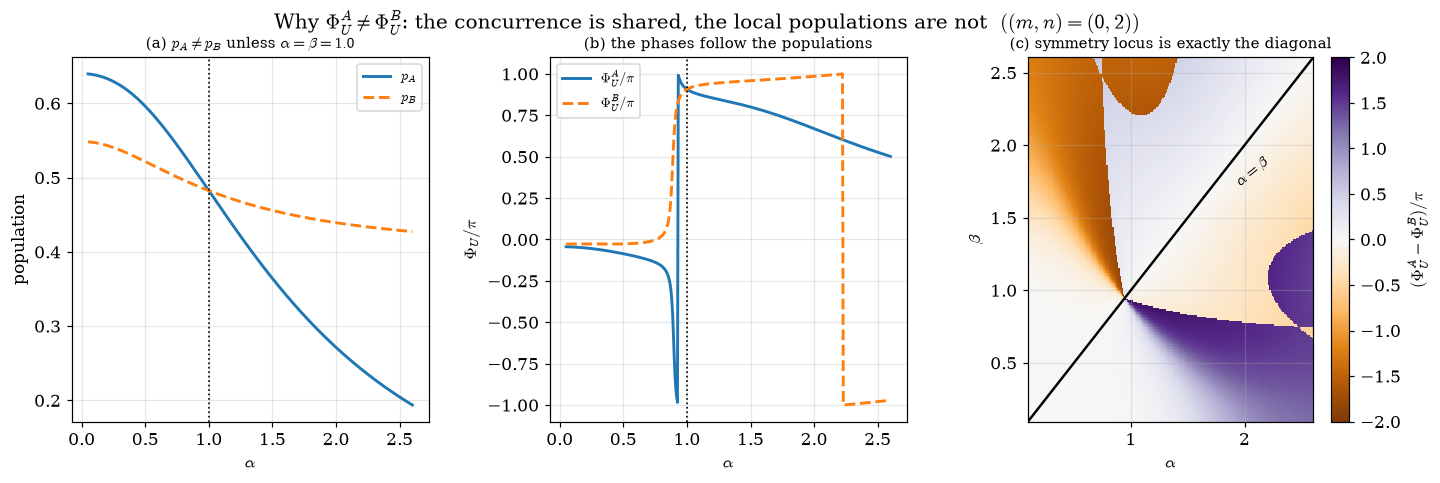

In [11]:

# ============================================================
# Celda 9bis — Origen de la asimetría A/B, y figura 11
# ============================================================
def tilt(p, C):
    """Inclinación theta entre el vector de Bloch reducido y el eje sigma_z local."""
    r = np.sqrt(1 - C**2)
    return np.degrees(np.arccos(np.clip((1 - 2*p)/r, -1, 1)))

print("C es COMPARTIDA; p y theta NO lo son:")
print(f"{'a':>5}{'b':>5}{'(m,n)':>8} | {'C':>9} | {'p_A':>9}{'p_B':>9} | "
      f"{'th_A':>8}{'th_B':>8}")
worst = 0.0
for (a,b,m,n,mu) in [(1.1,0.8,0,2,0.6),(1.3,0.7,1,3,0.45),(0.9,1.6,0,1,0.7)]:
    pA,pB,C,wA,wB = params('correlated',a,b,m,n,mu)
    # equivalencia de las dos expresiones de b
    for p_,w_ in [(pA,wA),(pB,wB)]:
        r = np.sqrt(1-C**2); ct = (1-2*p_)/r; st = np.sqrt(max(1-ct**2,0))
        worst = max(worst, abs(w_*np.sqrt(ct**2+C**2*st**2) - uhlmann_b(p_,C,w_)))
    print(f"{a:5.2f}{b:5.2f}{f'({m},{n})':>8} | {C:9.6f} | {pA:9.6f}{pB:9.6f} | "
          f"{tilt(pA,C):7.2f}°{tilt(pB,C):7.2f}°")
print("\nEquivalencia b = w sqrt(cos^2 th + C^2 sin^2 th):", worst)
assert worst < 1e-12

def figura11(m=0, n=2, mu=0.6, res=240):
    """Origen de la asimetría: p_A - p_B, y su efecto en Phi_U."""
    fig, axes = plt.subplots(1, 3, figsize=(15.4, 4.3))
    al = np.linspace(0.05, 2.6, 400); beta = 1.0

    pAs = [params('correlated', a, beta, m, n, mu)[0] for a in al]
    pBs = [params('correlated', a, beta, m, n, mu)[1] for a in al]
    axes[0].plot(al, pAs, lw=1.9, label=r"$p_A$")
    axes[0].plot(al, pBs, lw=1.9, ls="--", label=r"$p_B$")
    axes[0].axvline(beta, color="k", ls=":", lw=1.1)
    axes[0].set_xlabel(r"$\alpha$"); axes[0].set_ylabel("population")
    axes[0].set_title(rf"(a) $p_A\neq p_B$ unless $\alpha=\beta={beta}$", fontsize=10)
    axes[0].legend(fontsize=9)

    A, B = [], []
    for a in al:
        pA,pB,C,wA,wB = params('correlated', a, beta, m, n, mu)
        A.append(uhlmann_phase(pA,C,wA)/np.pi); B.append(uhlmann_phase(pB,C,wB)/np.pi)
    axes[1].plot(al, A, lw=1.9, label=r"$\Phi_U^A/\pi$")
    axes[1].plot(al, B, lw=1.9, ls="--", label=r"$\Phi_U^B/\pi$")
    axes[1].axvline(beta, color="k", ls=":", lw=1.1)
    axes[1].set_xlabel(r"$\alpha$"); axes[1].set_ylabel(r"$\Phi_U/\pi$")
    axes[1].set_title(r"(b) the phases follow the populations", fontsize=10)
    axes[1].legend(fontsize=9)

    ab = np.linspace(0.1, 2.6, res)
    AA, BB = np.meshgrid(ab, ab)
    Dif = np.zeros_like(AA)
    for i in range(res):
        for j in range(res):
            pA,pB,C,wA,wB = params('correlated', AA[i,j], BB[i,j], m, n, mu)
            Dif[i,j] = (uhlmann_phase(pA,C,wA) - uhlmann_phase(pB,C,wB))/np.pi
    im = axes[2].pcolormesh(AA, BB, Dif, shading="auto", cmap="PuOr",
                            vmin=-2, vmax=2)
    fig.colorbar(im, ax=axes[2]).set_label(r"$(\Phi_U^A-\Phi_U^B)/\pi$")
    axes[2].plot([0.1,2.6],[0.1,2.6],"k-",lw=1.6)
    axes[2].text(1.9, 1.72, r"$\alpha=\beta$", fontsize=10, rotation=39)
    axes[2].set_xlabel(r"$\alpha$"); axes[2].set_ylabel(r"$\beta$")
    axes[2].set_title(r"(c) symmetry locus is exactly the diagonal", fontsize=10)

    fig.suptitle(r"Why $\Phi_U^A\neq\Phi_U^B$: the concurrence is shared, "
                 r"the local populations are not  $((m,n)=(0,2))$")
    fig.subplots_adjust(wspace=0.34)
    savefig(fig, "fig11_AB_asymmetry"); plt.show(); return fig

figura11();



## 8ter. La fase de Uhlmann como función de la concurrencia

La fórmula general $b=\omega\sqrt{1+C^2-4p(1-p)}$ mezcla $C$ con la población.
Conviene ver en qué lugares $b$ (y por tanto $\Phi_U$) se vuelve función
**pura** de la concurrencia.

### 8ter.1 Coordenadas $(C,\eta)$: lo que fija el entrelazamiento y lo que no

En la familia correlacionada **balanceada** ($\mu=\nu=1/\sqrt2$) se cumple una
identidad exacta que conecta ambos subsistemas con la concurrencia compartida:
$$
\boxed{\;\sqrt{p_A\,p_B}=\frac{C}{2}\;}
$$
Definiendo la **asimetría local**
$$
\eta\equiv\sqrt{\frac{p_A}{p_B}}=\sqrt{\frac{1-q_\alpha}{1-q_\beta}} ,
$$
las poblaciones quedan parametrizadas como
$$
p_A=\frac{C}{2}\,\eta,\qquad p_B=\frac{C}{2\eta} .
$$
Esto separa limpiamente los dos papeles: **$C$ fija la media geométrica de las
poblaciones; $\eta$ es el grado de libertad local que el entrelazamiento no
determina.** La simetría $A\leftrightarrow B$ es exactamente $\eta=1$, es decir
$q_\alpha=q_\beta$, es decir $\beta=\alpha$.

**Región física.** Exigir $p(1-p)\ge\det\rho=C^2/4$ en ambos lados da
$C\eta^2-2\eta+C\le0$, o sea
$$
\eta\in\left[\frac{1-r}{C},\ \frac{1+r}{C}\right],\qquad r=\sqrt{1-C^2},
$$
un intervalo simétrico bajo $\eta\to1/\eta$ (el producto de sus extremos es
exactamente 1). Al aumentar $C$ el intervalo se estrecha, y

$$
\boxed{\;C\to1\ \Longrightarrow\ \eta\to1\;}
$$

**el entrelazamiento máximo fuerza la simetría entre subsistemas**: en el
límite $C=1$ se tiene $p_A=p_B=1/2$ obligatoriamente, luego
$\Phi_U^A=\Phi_U^B$. La asimetría es un lujo que sólo se puede permitir el
entrelazamiento parcial.

### 8ter.2 Familia balanceada simétrica: $\Phi_U$ función pura de $C$

Con $\beta=\alpha$ y $\mu=\nu$ se tiene $\eta=1$, luego
$$
p=\frac{C}{2}
\qquad\Longrightarrow\qquad
1+C^2-4p(1-p)=C^2+(1-C)^2 ,
$$
y por tanto
$$
\boxed{\;b=\Delta\sqrt{C^2+(1-C)^2},\qquad
\Phi_U=\Arg\!\Big[(-1)^\Delta\cos(\pi b)-i\frac{\Delta(1-C)}{b}\sin(\pi b)\Big]\;}
$$
una función **exclusivamente de $C$ y $\Delta$**. Su rango es
$b\in[\Delta/\sqrt2,\ \Delta]$, con el mínimo en $C=1/2$ y $b=\Delta$ en ambos
extremos $C\to0$ y $C\to1$.

### 8ter.3 Sobre $p=1/2$: cuantización $\mathbb{Z}_2$

En el lugar donde viven los nodos, $p=1/2$, la parte imaginaria de $Z_U$ se
anula **idénticamente** (lleva el factor $1-2p$) y $b=\Delta C$. Entonces
$$
Z_U=(-1)^{\Delta}\cos(\pi\Delta C)\in\mathbb R
\qquad\Longrightarrow\qquad
\boxed{\;\Phi_U\in\{0,\pi\}\;}
$$
La fase de Uhlmann deja de ser continua y se convierte en un **índice
$\mathbb{Z}_2$** función únicamente de la concurrencia: vale $0$ donde
$(-1)^\Delta\cos(\pi\Delta C)>0$ y $\pi$ donde es negativo. Los **nodos son
exactamente las paredes de dominio** entre ambos valores.



## 8quater. Cuantización de la concurrencia en los puntos singulares

Sobre $p=1/2$ el parámetro $b=\Delta C$ actúa como un **número de enrollamiento
efectivo** que la concurrencia sintoniza de forma continua:
$$
\omega_{\rm eff}\equiv b\big|_{p=1/2}=\Delta\,C
\qquad\text{recorre } [0,\Delta] \text{ cuando } C\in[0,1].
$$
La condición nodal $|b|=k+\tfrac12$ es entonces la de que ese enrollamiento
efectivo pase por un **semientero**:
$$
\boxed{\;\Delta\,C_k=k+\tfrac12
\qquad\Longleftrightarrow\qquad
C_k=\frac{2k+1}{2\Delta},\qquad k=0,1,\dots,\Delta-1\;}
$$

Consecuencias:

1. **Número de nodos.** Como $C\le1$, sólo caben $k\le\Delta-1$: hay
   **exactamente $\Delta$ singularidades**, ni una más. La separación de
   adición fotónica $\Delta=n-m$ *cuenta* literalmente los puntos singulares.
2. **Espaciado uniforme.** $C_{k+1}-C_k=1/\Delta$: las concurrencias
   singulares son equidistantes, y son los múltiplos **impares** de
   $1/2\Delta$.
3. **Simetría del conjunto.** $C_k+C_{\Delta-1-k}=1$: la escalera es simétrica
   respecto de $C=1/2$.
4. **Índice $\mathbb{Z}_2$.** Al cruzar cada $C_k$ la fase salta de $0$ a $\pi$
   o viceversa; entre $C=0$ y $C=1$ hay exactamente $\Delta$ saltos.
5. **Compartidos por ambos subsistemas.** Sólo entra $|\omega_s|=\Delta$ y la
   concurrencia es compartida, así que $A$ y $B$ tienen la **misma** escalera
   $\{C_k\}$, aunque no las mismas coordenadas $(\mu,\alpha)$.

Traducido al espacio de parámetros: en la familia simétrica $C=1-2q$ sobre
$p=1/2$, de modo que cada $C_k$ fija un solapamiento
$q_k=(1-C_k)/2$ y con él una amplitud $\alpha_k$. Como
$C_k\ge1/(2\Delta)>0$, siempre $q_k<1/2$ y por tanto $\alpha_k<\alpha_g$.


In [12]:

# ============================================================
# Celda 9ter — Uhlmann como función de C: identidades y cuantización
# ============================================================
print("(1)  sqrt(p_A p_B) = C/2   (familia correlacionada balanceada)")
worst = 0.0
for (a, b, m, n) in [(1.1,0.8,0,2),(1.3,0.7,1,3),(0.9,1.6,0,1),(2.0,1.2,2,5)]:
    pA, pB, C, wA, wB = params('correlated', a, b, m, n, BAL)
    worst = max(worst, abs(np.sqrt(pA*pB) - C/2))
    print(f"   a={a} b={b} ({m},{n}): p_A={pA:.8f} p_B={pB:.8f} "
          f"sqrt(pApB)={np.sqrt(pA*pB):.8f}  C/2={C/2:.8f}  "
          f"eta={np.sqrt(pA/pB):.6f}")
print("   peor dif:", worst); assert worst < 1e-12

print("\n(2)  beta=alpha balanceado:  p = C/2  y  b = Delta sqrt(C^2+(1-C)^2)")
worst = 0.0
for (a, m, n) in [(0.7,0,2),(1.3,0,2),(2.1,1,3),(0.5,0,4)]:
    pA, pB, C, wA, wB = params('correlated', a, a, m, n, BAL)
    D = n - m
    worst = max(worst, abs(pA - C/2),
                abs(uhlmann_b(pA, C, wA) - D*np.sqrt(C**2 + (1-C)**2)))
    print(f"   alpha={a} ({m},{n}) D={D}: C={C:.6f}  p={pA:.8f}(=C/2={C/2:.8f})  "
          f"b={uhlmann_b(pA,C,wA):.8f}(=D sqrt(..)={D*np.sqrt(C**2+(1-C)**2):.8f})")
print("   peor dif:", worst); assert worst < 1e-12

print("\n(3)  Sobre p=1/2:  b = Delta*C  y  Z_U real  =>  Phi_U in {0, pi}")
for D in [1, 2, 3]:
    vals = []
    for C in [0.1, 0.3, 0.5, 0.7, 0.9]:
        Z = uhlmann_ZU(0.5, C, D) if False else uhlmann_Z(0.5, C, D)
        vals.append(f"C={C}: Im={Z.imag:+.0e}, Phi/pi={np.angle(Z)/np.pi:.0f}")
    print(f"   Delta={D}: " + " | ".join(vals))

print("\n(4)  Región física de eta:  [(1-r)/C, (1+r)/C],  r=sqrt(1-C^2)")
for C in [0.2, 0.5, 0.9, 0.99, 1.0]:
    r = np.sqrt(max(1-C**2, 0))
    lo, hi = (1-r)/C, (1+r)/C
    print(f"   C={C:.2f}: eta in [{lo:.4f}, {hi:.4f}]   producto={lo*hi:.8f}"
          f"   (C->1 fuerza eta->1)")

print("\n(5)  Cuantización:  Delta*C_k = k+1/2,  exactamente Delta nodos")
for D in [1, 2, 3, 4]:
    Cs = [nodal_Ck(k, D) for k in nodal_k_range(D)]
    print(f"   Delta={D}: C_k = {['%.4f' % c for c in Cs]}   "
          f"D*C_k = {['%.1f' % (D*c) for c in Cs]}   "
          f"suma simetrica C_k+C_(D-1-k) = "
          f"{['%.2f' % (Cs[k]+Cs[D-1-k]) for k in range(D)]}")


(1)  sqrt(p_A p_B) = C/2   (familia correlacionada balanceada)
   a=1.1 b=0.8 (0,2): p_A=0.36753885 p_B=0.40943327 sqrt(pApB)=0.38792091  C/2=0.38792091  eta=0.947458
   a=1.3 b=0.7 (1,3): p_A=0.27130069 p_B=0.36880689 sqrt(pApB)=0.31631877  C/2=0.31631877  eta=0.857681
   a=0.9 b=1.6 (0,1): p_A=0.17625627 p_B=0.08961344 sqrt(pApB)=0.12567788  C/2=0.12567788  eta=1.402445
   a=2.0 b=1.2 (2,5): p_A=0.27320089 p_B=0.35497691 sqrt(pApB)=0.31141614  C/2=0.31141614  eta=0.877286
   peor dif: 1.1102230246251565e-16

(2)  beta=alpha balanceado:  p = C/2  y  b = Delta sqrt(C^2+(1-C)^2)
   alpha=0.7 (0,2) D=2: C=0.891852  p=0.44592586(=C/2=0.44592586)  b=1.79676992(=D sqrt(..)=1.79676992)
   alpha=1.3 (0,2) D=2: C=0.605298  p=0.30264922(=C/2=0.30264922)  b=1.44523427(=D sqrt(..)=1.44523427)
   alpha=2.1 (1,3) D=2: C=0.273735  p=0.13686774(=C/2=0.13686774)  b=1.55227738(=D sqrt(..)=1.55227738)
   alpha=0.5 (0,4) D=4: C=0.999852  p=0.49992596(=C/2=0.49992596)  b=3.99940771(=D sqrt(..)=3.99940771)

[guardado] figures/fig12_concurrence_pacs.pdf


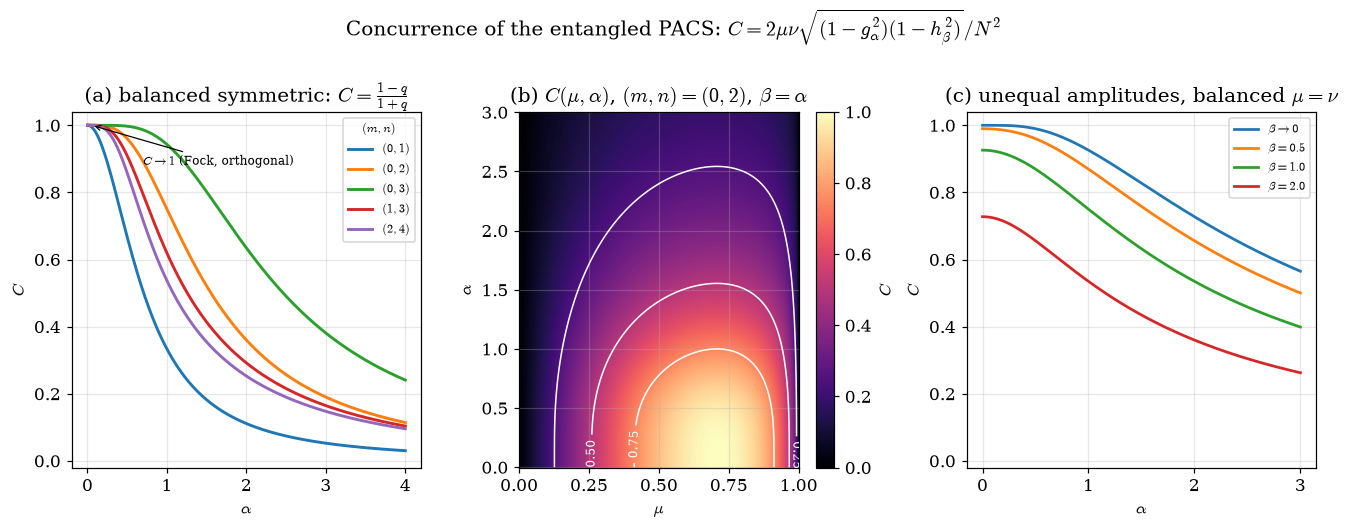

[guardado] figures/fig13_uhlmann_vs_concurrence.pdf


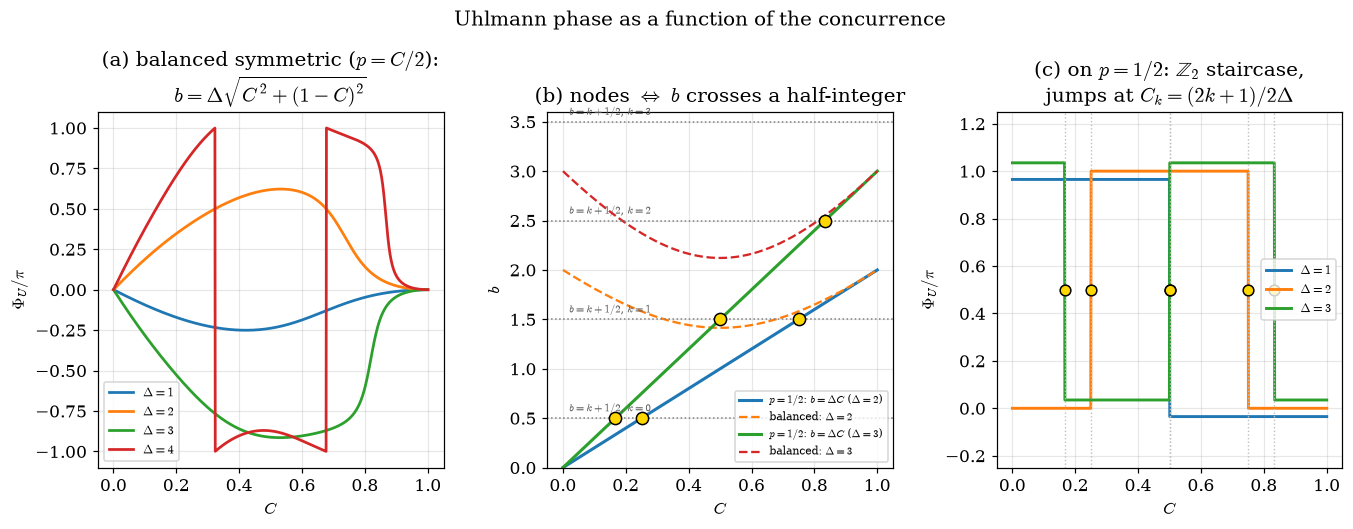

[guardado] figures/fig14_C_eta_plane.pdf


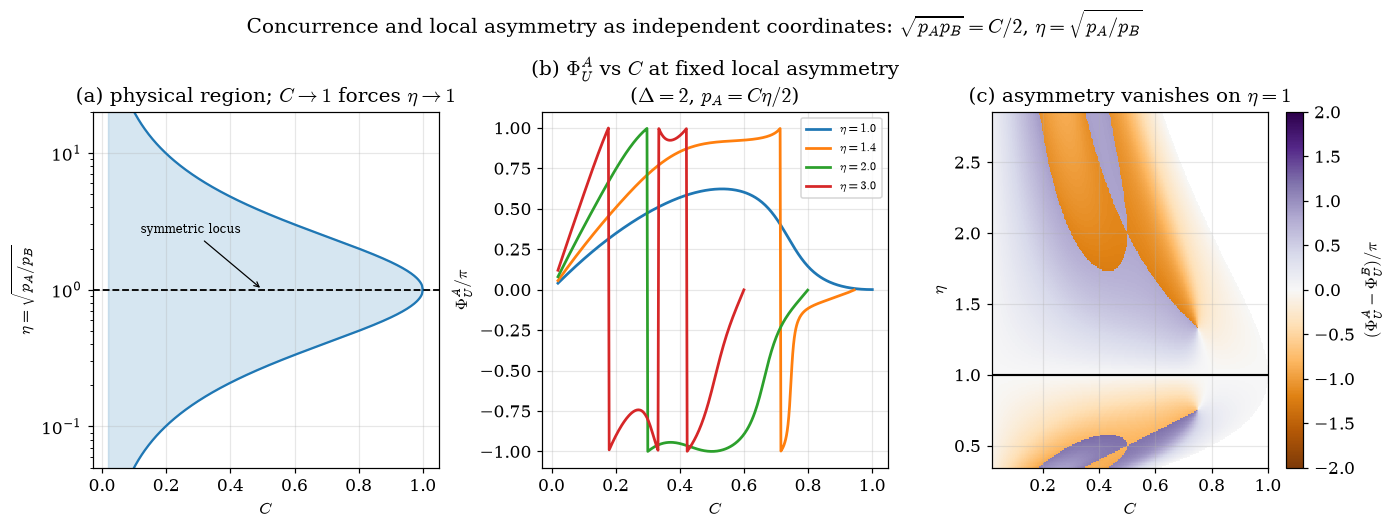

In [13]:

# ============================================================
# Celda 10bis — Figuras 12-14
# ============================================================
def figura12():
    """Concurrencia del PACS entrelazado."""
    fig, axes = plt.subplots(1, 3, figsize=(14.6, 4.2))
    al = np.linspace(1e-4, 4.0, 500)
    for (m, n) in [(0,1),(0,2),(0,3),(1,3),(2,4)]:
        axes[0].plot(al, [C_pacs(BAL, a, a, m, n) for a in al],
                     lw=1.9, label=f"$({m},{n})$")
    axes[0].set_xlabel(r"$\alpha$"); axes[0].set_ylabel(r"$C$")
    axes[0].set_ylim(-0.02, 1.04)
    axes[0].set_title(r"(a) balanced symmetric: $C=\frac{1-q}{1+q}$")
    axes[0].legend(fontsize=8, title=r"$(m,n)$", title_fontsize=8)
    axes[0].annotate(r"$C\to1$ (Fock, orthogonal)", xy=(0.05, 1.0),
                     xytext=(0.7, 0.88), fontsize=8,
                     arrowprops=dict(arrowstyle="->", lw=0.8))

    mus = np.linspace(0.001, 0.999, 420); als = np.linspace(1e-3, 3.0, 420)
    MU, AL = np.meshgrid(mus, als)
    Z = np.vectorize(lambda u, a: C_pacs(u, a, a, 0, 2))(MU, AL)
    im = axes[1].pcolormesh(MU, AL, Z, shading="auto", cmap="magma",
                            vmin=0, vmax=1, rasterized=True)
    fig.colorbar(im, ax=axes[1]).set_label(r"$C$")
    cs = axes[1].contour(MU, AL, Z, levels=[0.25,0.5,0.75], colors="w", linewidths=1.0)
    axes[1].clabel(cs, fmt="%.2f", fontsize=8)
    axes[1].set_xlabel(r"$\mu$"); axes[1].set_ylabel(r"$\alpha$")
    axes[1].set_title(r"(b) $C(\mu,\alpha)$, $(m,n)=(0,2)$, $\beta=\alpha$")

    al = np.linspace(1e-4, 3.0, 400)
    for beta in [0.0001, 0.5, 1.0, 2.0]:
        lab = r"$\beta\to0$" if beta < 1e-3 else rf"$\beta={beta}$"
        axes[2].plot(al, [C_pacs(BAL, a, beta, 0, 2) for a in al], lw=1.8, label=lab)
    axes[2].set_xlabel(r"$\alpha$"); axes[2].set_ylabel(r"$C$")
    axes[2].set_ylim(-0.02, 1.04)
    axes[2].set_title(r"(c) unequal amplitudes, balanced $\mu=\nu$")
    axes[2].legend(fontsize=8)
    fig.suptitle(r"Concurrence of the entangled PACS: "
                 r"$C=2\mu\nu\sqrt{(1-g_\alpha^2)(1-h_\beta^2)}/N^2$", y=1.10)
    fig.subplots_adjust(wspace=0.28)
    savefig(fig, "fig12_concurrence_pacs"); plt.show(); return fig

def figura13():
    """Fase de Uhlmann como función de la concurrencia."""
    fig, axes = plt.subplots(1, 3, figsize=(14.6, 4.2))
    Cs = np.linspace(1e-4, 1.0, 900)
    for D in [1,2,3,4]:
        b = D*np.sqrt(Cs**2 + (1-Cs)**2)
        Z = (-1.0)**D*np.cos(np.pi*b) - 1j*(D*(1-Cs)/b)*np.sin(np.pi*b)
        axes[0].plot(Cs, np.angle(Z)/np.pi, lw=1.8, label=rf"$\Delta={D}$")
    axes[0].set_xlabel(r"$C$"); axes[0].set_ylabel(r"$\Phi_U/\pi$")
    axes[0].set_title(r"(a) balanced symmetric ($p=C/2$):" "\n"
                      r"$b=\Delta\sqrt{C^2+(1-C)^2}$")
    axes[0].legend(fontsize=8)

    for D in [2,3]:
        axes[1].plot(Cs, D*Cs, lw=2.0, label=rf"$p=1/2$: $b=\Delta C$ ($\Delta={D}$)")
        axes[1].plot(Cs, D*np.sqrt(Cs**2+(1-Cs)**2), lw=1.5, ls="--",
                     label=rf"balanced: $\Delta={D}$")
    for k in range(4):
        axes[1].axhline(k+0.5, color="0.5", ls=":", lw=1.0)
        axes[1].text(0.02, k+0.56, rf"$b=k+1/2$, $k={k}$", fontsize=7, color="0.35")
    for D in [2,3]:
        for k in nodal_k_range(D):
            axes[1].plot(nodal_Ck(k,D), k+0.5, "o", color="gold", mec="k", ms=8, zorder=5)
    axes[1].set_xlabel(r"$C$"); axes[1].set_ylabel(r"$b$"); axes[1].set_ylim(0,3.6)
    axes[1].set_title(r"(b) nodes $\Leftrightarrow$ $b$ crosses a half-integer")
    axes[1].legend(fontsize=7, loc="lower right")

    for D in [1,2,3]:
        ph = np.array([uhlmann_phase(0.5, C, D)/np.pi for C in Cs])
        axes[2].plot(Cs, ph + 0.035*(D-2), lw=1.9, label=rf"$\Delta={D}$")
        for k in nodal_k_range(D):
            axes[2].axvline(nodal_Ck(k,D), color="0.75", ls=":", lw=0.9)
    for D in [1,2,3]:
        for k in nodal_k_range(D):
            axes[2].plot(nodal_Ck(k,D), 0.5, "o", color="gold", mec="k", ms=7, zorder=5)
    axes[2].set_xlabel(r"$C$"); axes[2].set_ylabel(r"$\Phi_U/\pi$")
    axes[2].set_ylim(-0.25, 1.25)
    axes[2].set_title(r"(c) on $p=1/2$: $\mathbb{Z}_2$ staircase," "\n"
                      r"jumps at $C_k=(2k+1)/2\Delta$")
    axes[2].legend(fontsize=8, loc="center right")
    fig.suptitle(r"Uhlmann phase as a function of the concurrence", y=1.10)
    fig.subplots_adjust(wspace=0.30)
    savefig(fig, "fig13_uhlmann_vs_concurrence"); plt.show(); return fig

def figura14(D=2):
    """Plano (C, eta): concurrencia compartida vs. asimetría local."""
    fig, axes = plt.subplots(1, 3, figsize=(14.6, 4.2))
    Cs = np.linspace(0.02, 1.0, 400)
    r = np.sqrt(np.clip(1-Cs**2, 0, None))
    lo, hi = (1-r)/Cs, (1+r)/Cs
    axes[0].fill_between(Cs, lo, hi, color="C0", alpha=0.18)
    axes[0].plot(Cs, lo, "C0", lw=1.5); axes[0].plot(Cs, hi, "C0", lw=1.5)
    axes[0].axhline(1, color="k", ls="--", lw=1.2)
    axes[0].set_yscale("log"); axes[0].set_ylim(0.05, 20)
    axes[0].set_xlabel(r"$C$"); axes[0].set_ylabel(r"$\eta=\sqrt{p_A/p_B}$")
    axes[0].set_title(r"(a) physical region; $C\to1$ forces $\eta\to1$")
    axes[0].annotate("symmetric locus", xy=(0.5,1), xytext=(0.12,2.6), fontsize=8,
                     arrowprops=dict(arrowstyle="->", lw=0.8))

    for eta in [1.0, 1.4, 2.0, 3.0]:
        ph = []
        for C, rr in zip(Cs, r):
            if not ((1-rr)/C <= eta <= (1+rr)/C):
                ph.append(np.nan); continue
            ph.append(uhlmann_phase(C*eta/2, C, D)/np.pi)
        axes[1].plot(Cs, ph, lw=1.8, label=rf"$\eta={eta}$")
    axes[1].set_xlabel(r"$C$"); axes[1].set_ylabel(r"$\Phi_U^A/\pi$")
    axes[1].set_title(rf"(b) $\Phi_U^A$ vs $C$ at fixed local asymmetry"
                      "\n" rf"($\Delta={D}$, $p_A=C\eta/2$)")
    axes[1].legend(fontsize=8)

    etas = np.linspace(0.35, 2.85, 260)
    CC, EE = np.meshgrid(Cs, etas)
    Dif = np.full_like(CC, np.nan)
    for i in range(CC.shape[0]):
        for j in range(CC.shape[1]):
            C, e = CC[i,j], EE[i,j]
            rr = np.sqrt(max(1-C**2, 0))
            if not ((1-rr)/C <= e <= (1+rr)/C): continue
            Dif[i,j] = (uhlmann_phase(C*e/2, C, D)
                        - uhlmann_phase(C/(2*e), C, D))/np.pi
    im = axes[2].pcolormesh(CC, EE, Dif, shading="auto", cmap="PuOr",
                            vmin=-2, vmax=2, rasterized=True)
    fig.colorbar(im, ax=axes[2]).set_label(r"$(\Phi_U^A-\Phi_U^B)/\pi$")
    axes[2].axhline(1, color="k", lw=1.4)
    axes[2].set_xlabel(r"$C$"); axes[2].set_ylabel(r"$\eta$")
    axes[2].set_title(r"(c) asymmetry vanishes on $\eta=1$")
    fig.suptitle(r"Concurrence and local asymmetry as independent coordinates: "
                 r"$\sqrt{p_Ap_B}=C/2$, $\eta=\sqrt{p_A/p_B}$", y=1.10)
    fig.subplots_adjust(wspace=0.30)
    savefig(fig, "fig14_C_eta_plane"); plt.show(); return fig

for f in [figura12, figura13, figura14]:
    f()



## 9. Figuras

Diez figuras que cubren la geometría de Berry (Figs. 1–5) y la de Uhlmann
(Figs. 6–10) bajo el ciclo global. Cada una se muestra en pantalla y se guarda
como PDF vectorial en `figures/`.


[guardado] figures/fig1_berry_global_vs_alpha.pdf


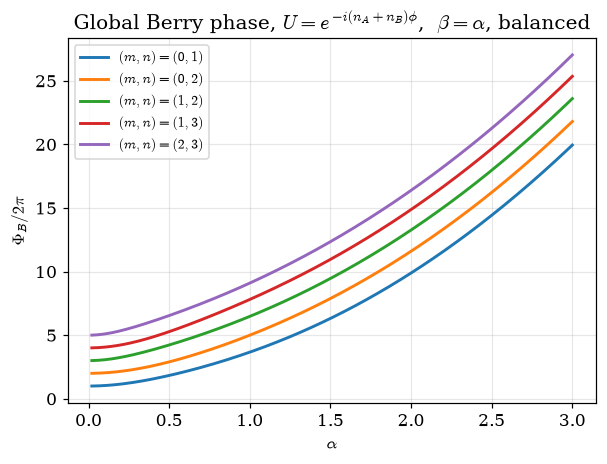

[guardado] figures/fig2_berry_global_indices.pdf


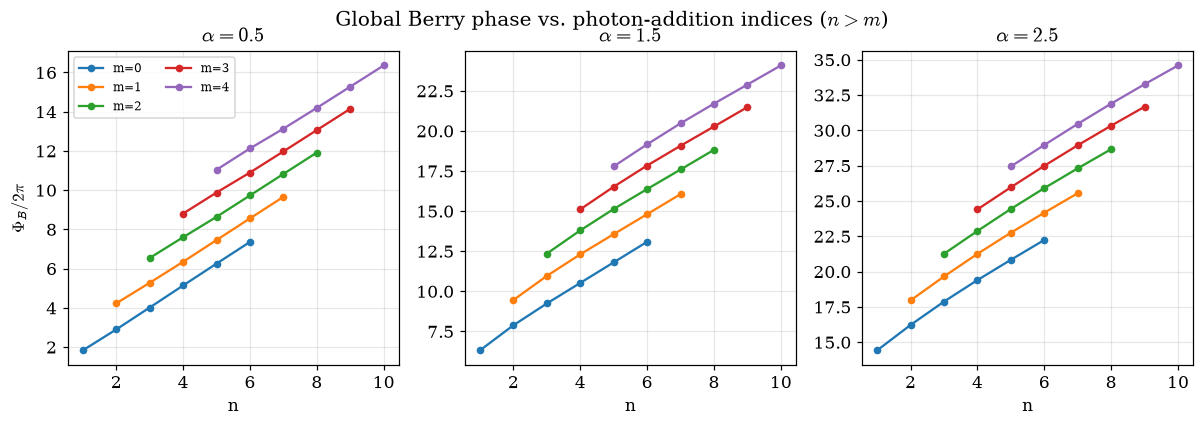

[guardado] figures/fig3_berry_global_chi.pdf


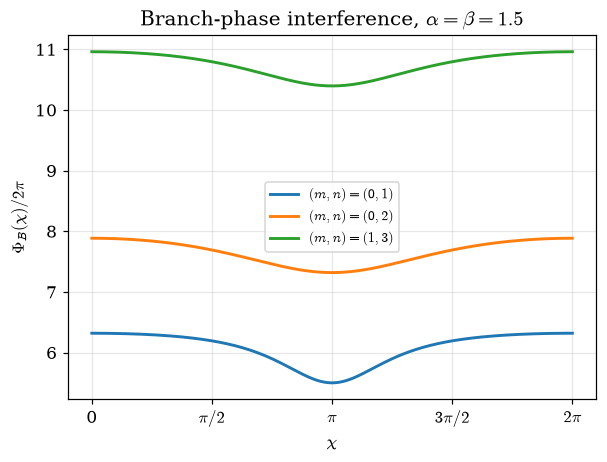

[guardado] figures/fig4_berry_global_map.pdf


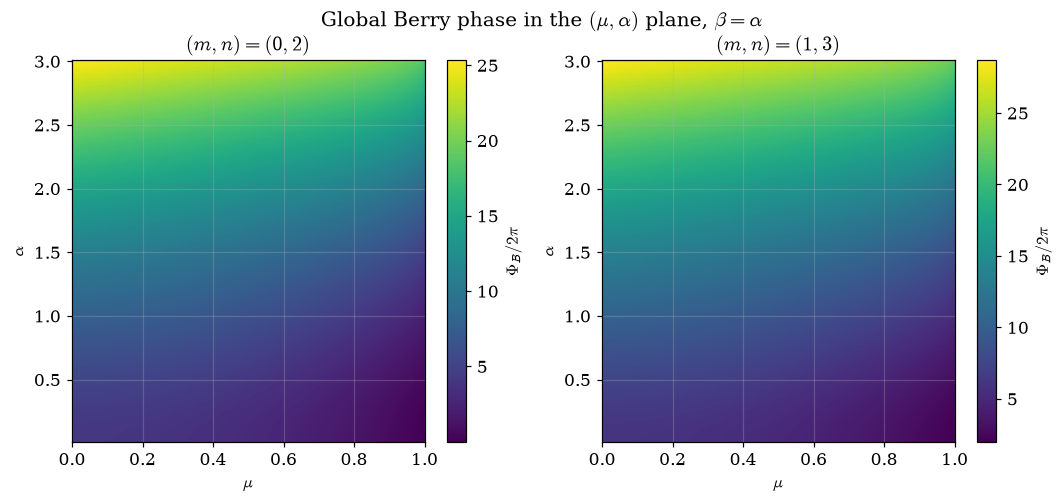

[guardado] figures/fig5_berry_mode_decomposition.pdf


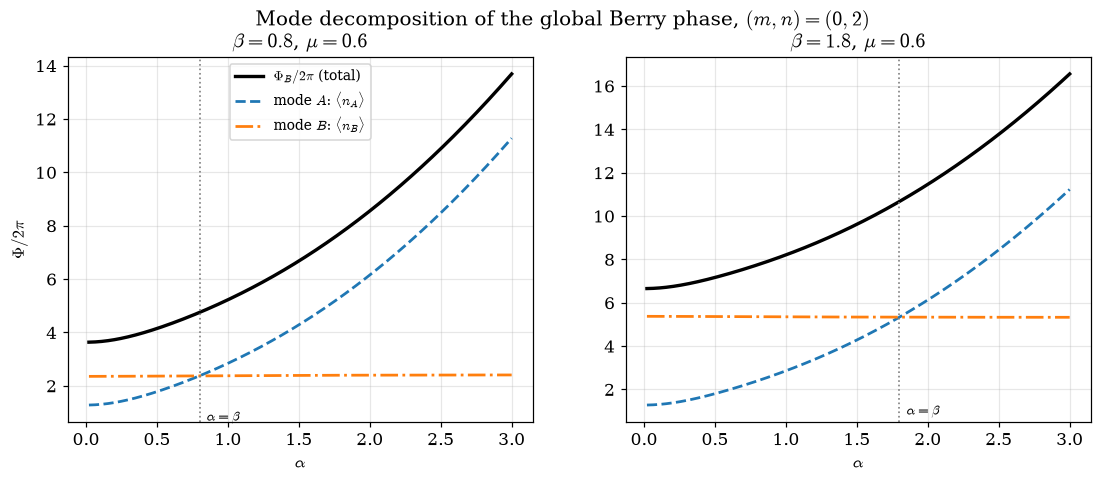

[guardado] figures/fig6_uhlmann_map_A.pdf


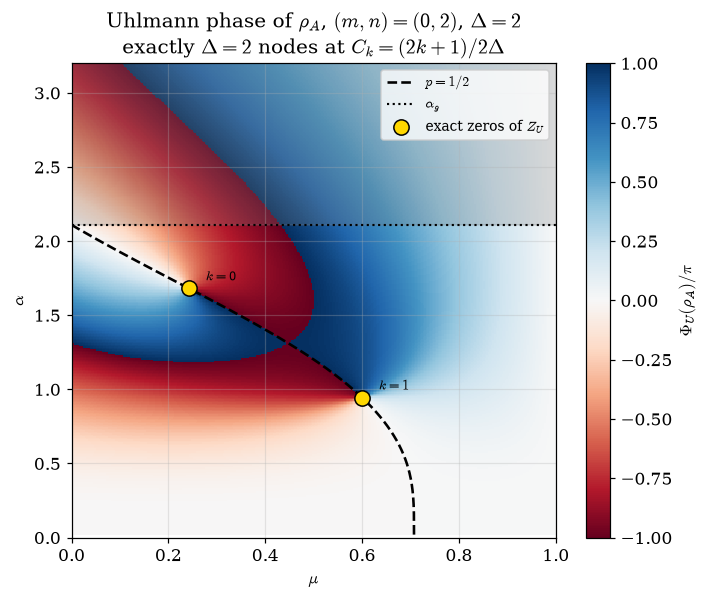

[guardado] figures/fig7_uhlmann_both.pdf


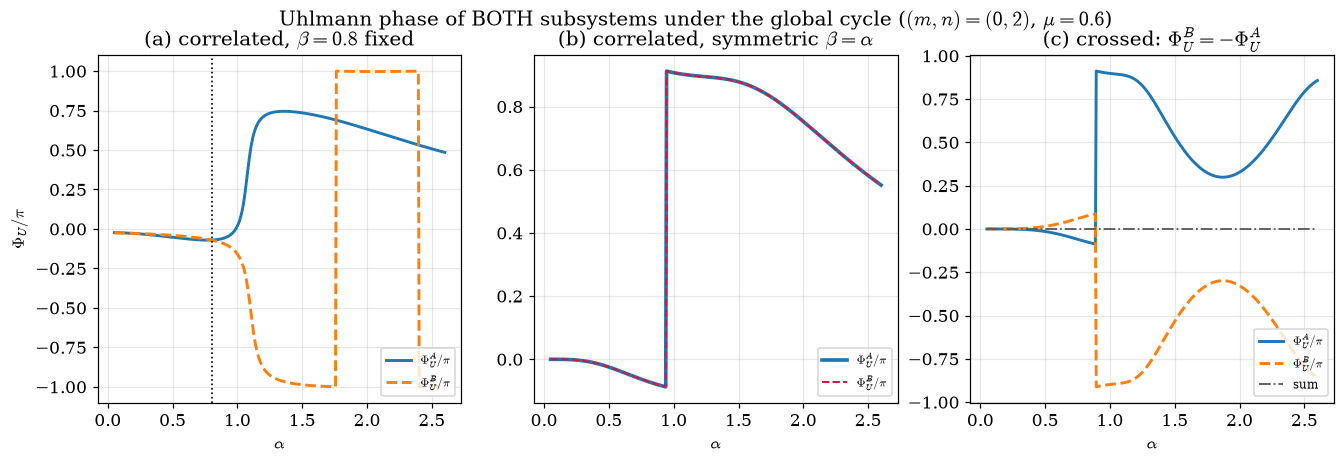

[guardado] figures/fig8_nodes_both.pdf


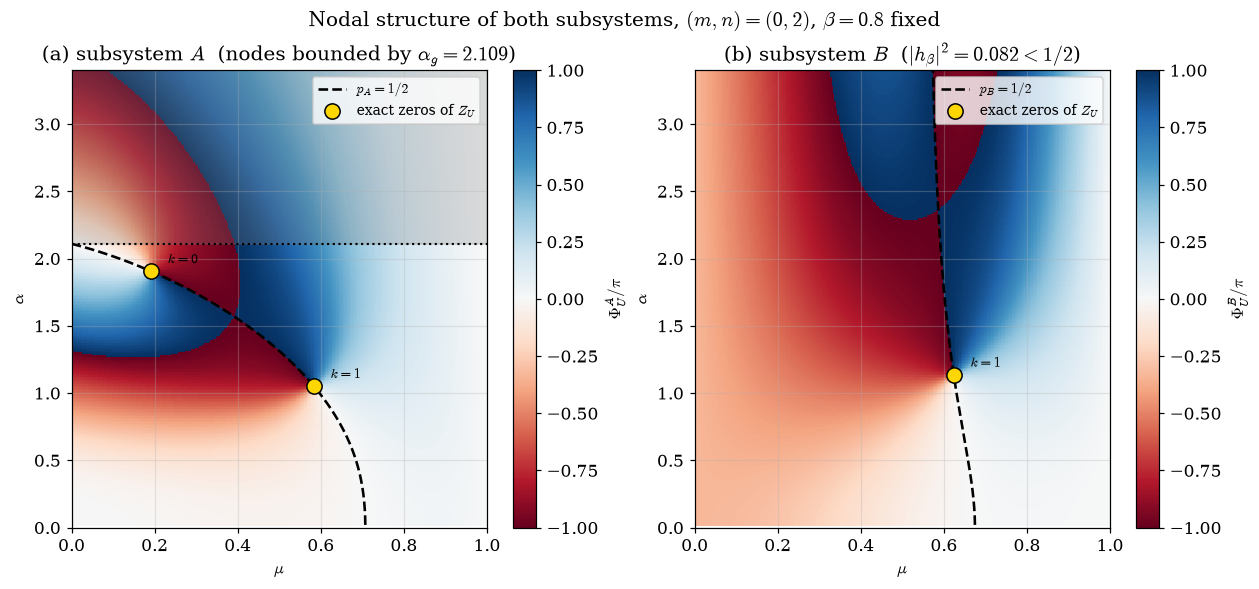

[guardado] figures/fig9_critical_overlap.pdf


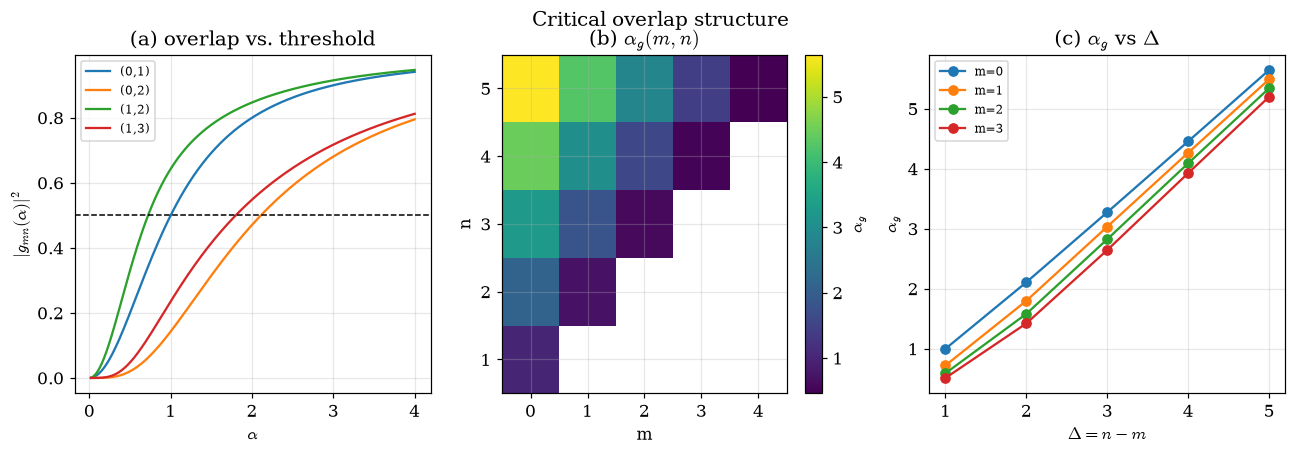

[guardado] figures/fig10_uhlmann_vs_Delta.pdf


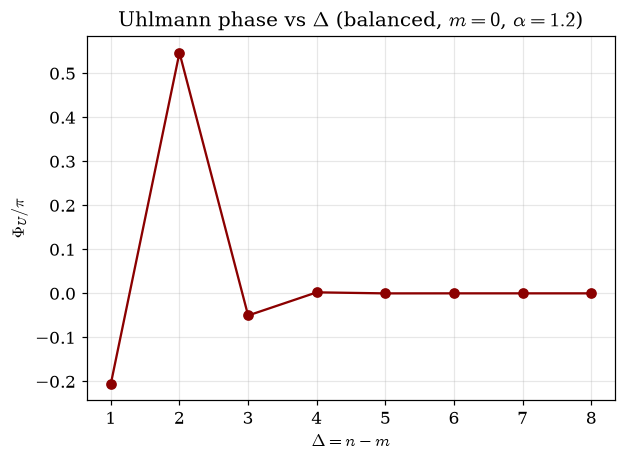

[guardado] figures/fig11_AB_asymmetry.pdf


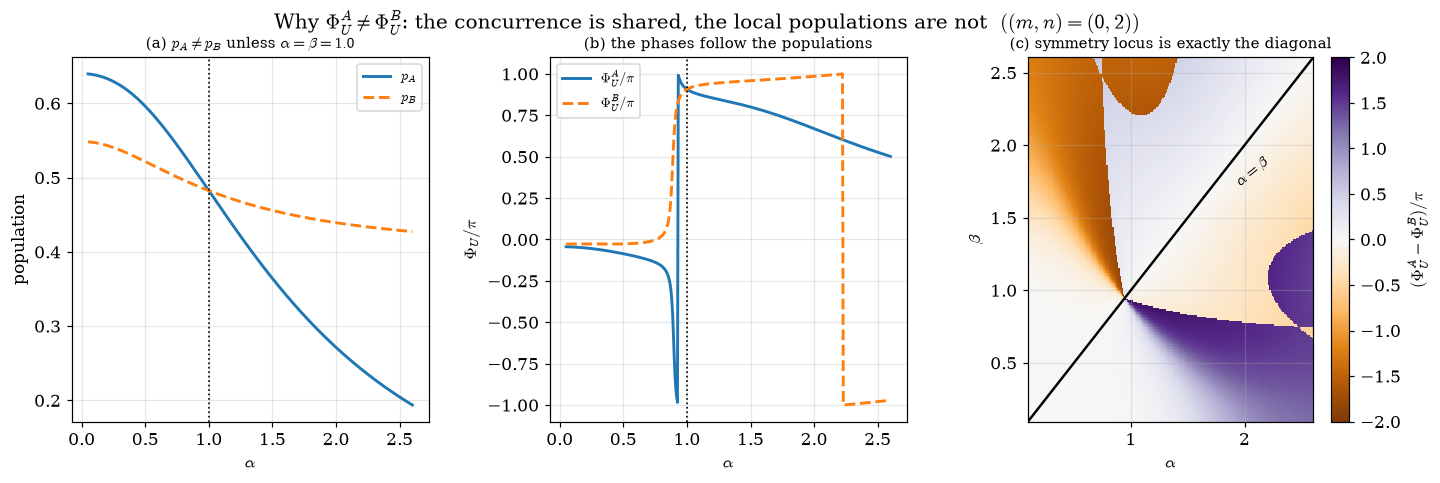

[guardado] figures/fig12_concurrence_pacs.pdf


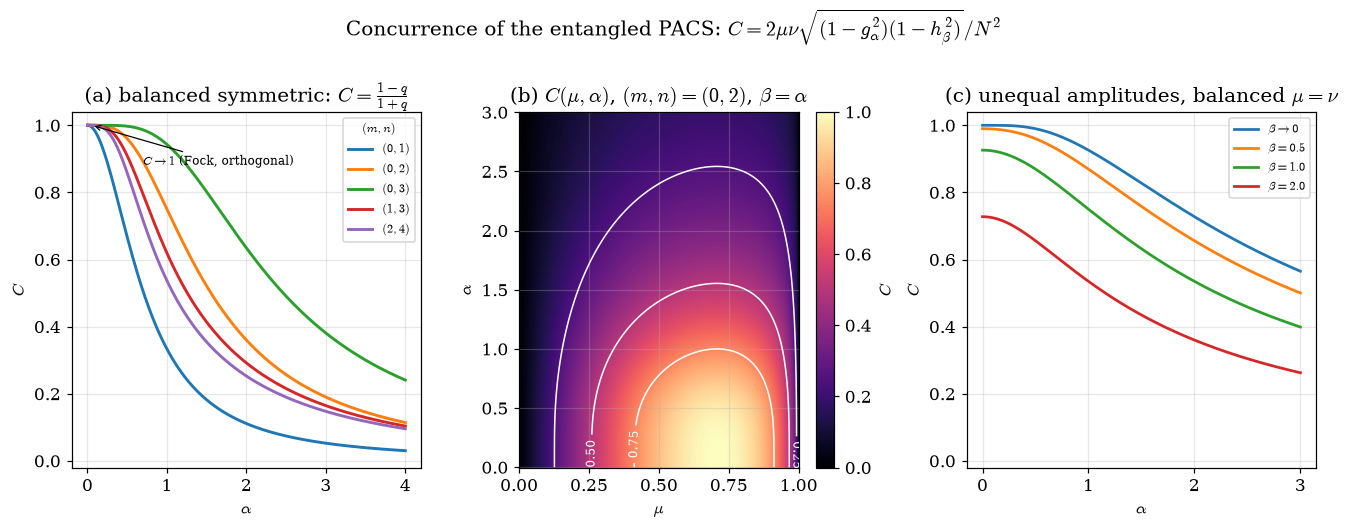

[guardado] figures/fig13_uhlmann_vs_concurrence.pdf


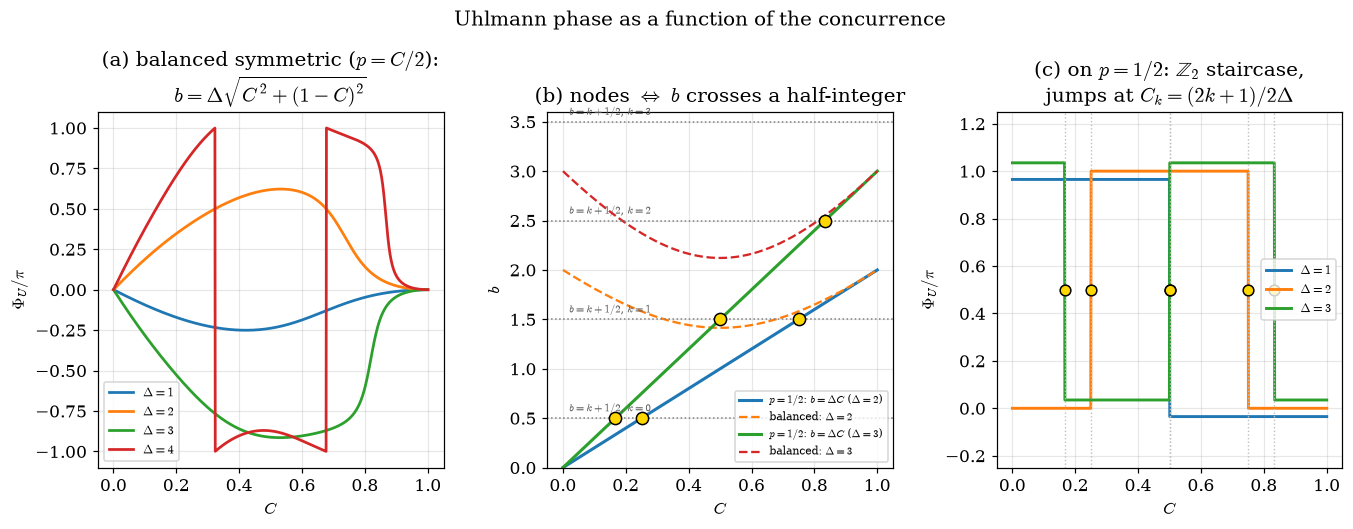

[guardado] figures/fig14_C_eta_plane.pdf


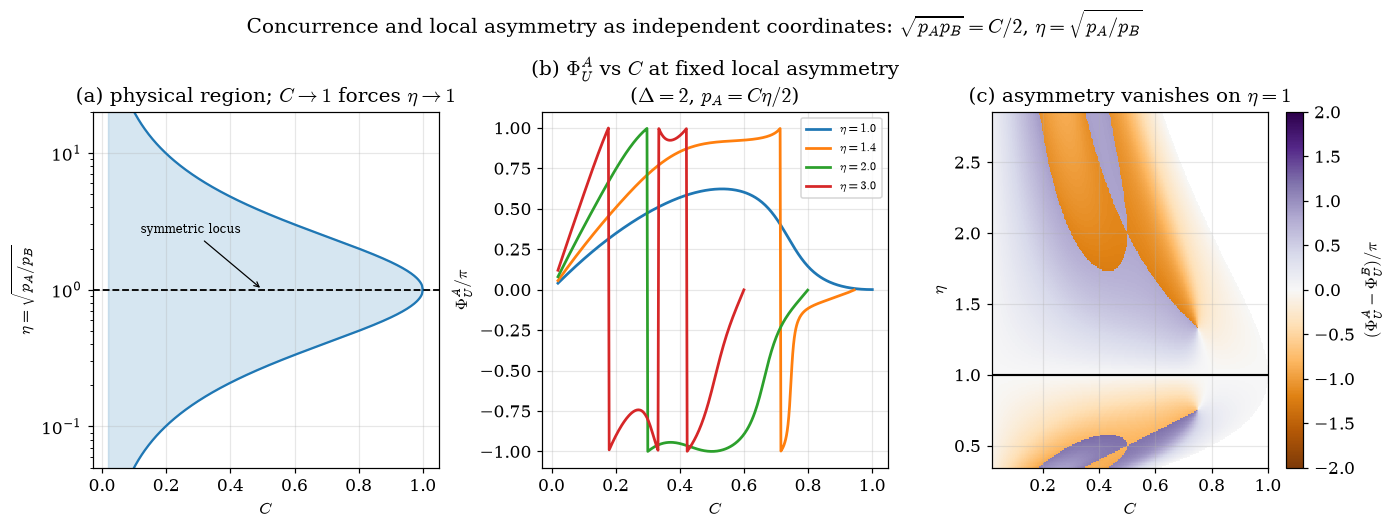

In [14]:

# ============================================================
# Celda 10 — Todas las figuras
# ============================================================
def figura1():
    """Fase de Berry global vs. alpha, estado balanceado simétrico."""
    al = np.linspace(0.02, 3.0, 300)
    fig, ax = plt.subplots(figsize=(6.2, 4.3))
    for (m, n) in [(0,1),(0,2),(1,2),(1,3),(2,3)]:
        ax.plot(al, [berry_global(a, a, m, n, BAL) for a in al],
                lw=1.9, label=f"$(m,n)=({m},{n})$")
    ax.set_xlabel(r"$\alpha$"); ax.set_ylabel(r"$\Phi_B/2\pi$")
    ax.set_title(r"Global Berry phase, $U=e^{-i(n_A+n_B)\phi}$,  $\beta=\alpha$, balanced")
    ax.legend(fontsize=9)
    savefig(fig, "fig1_berry_global_vs_alpha"); plt.show(); return fig

def figura2():
    """Dependencia discreta en los índices (m,n)."""
    fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.7))
    for ax, a in zip(axes, [0.5, 1.5, 2.5]):
        for m in range(5):
            ns = np.arange(m+1, m+7)
            ax.plot(ns, [berry_global(a, a, m, n, BAL) for n in ns], "o-", ms=4,
                    label=f"m={m}")
        ax.set_title(rf"$\alpha={a}$"); ax.set_xlabel("n")
    axes[0].set_ylabel(r"$\Phi_B/2\pi$"); axes[0].legend(fontsize=8, ncol=2)
    fig.suptitle("Global Berry phase vs. photon-addition indices ($n>m$)")
    savefig(fig, "fig2_berry_global_indices"); plt.show(); return fig

def figura3():
    """Interferencia inducida por la fase de rama chi."""
    chis = np.linspace(0, 2*np.pi, 400); a = 1.5
    fig, ax = plt.subplots(figsize=(6.2, 4.3))
    for (m, n) in [(0,1),(0,2),(1,3)]:
        ax.plot(chis, [berry_global(a, a, m, n, BAL, c) for c in chis],
                lw=1.9, label=f"$(m,n)=({m},{n})$")
    ax.set_xlabel(r"$\chi$"); ax.set_ylabel(r"$\Phi_B(\chi)/2\pi$")
    ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
    ax.set_xticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
    ax.set_title(rf"Branch-phase interference, $\alpha=\beta={a}$")
    ax.legend(fontsize=9)
    savefig(fig, "fig3_berry_global_chi"); plt.show(); return fig

def figura4():
    """Mapa de la fase de Berry global en el plano (mu, alpha)."""
    mus = np.linspace(0.001, 0.999, 220); als = np.linspace(0.02, 3.0, 220)
    MU, AL = np.meshgrid(mus, als)
    fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.5))
    for ax, (m, n) in zip(axes, [(0,2),(1,3)]):
        Z = np.vectorize(lambda u, a: berry_global(a, a, m, n, u))(MU, AL)
        im = ax.pcolormesh(MU, AL, Z, shading="auto", cmap="viridis")
        fig.colorbar(im, ax=ax).set_label(r"$\Phi_B/2\pi$")
        ax.set_xlabel(r"$\mu$"); ax.set_ylabel(r"$\alpha$")
        ax.set_title(f"$(m,n)=({m},{n})$")
    fig.suptitle(r"Global Berry phase in the $(\mu,\alpha)$ plane, $\beta=\alpha$")
    savefig(fig, "fig4_berry_global_map"); plt.show(); return fig

def figura5():
    """Descomposición por modos: el ciclo global reparte la fase entre A y B."""
    al = np.linspace(0.02, 3.0, 400)
    fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.3))
    for ax, beta in zip(axes, [0.8, 1.8]):
        m, n, mu = 0, 2, 0.6
        tot = np.array([berry_global(a, beta, m, n, mu) for a in al])
        pa = np.array([berry_partial(a, beta, m, n, mu, mode='A') for a in al])
        pb = np.array([berry_partial(a, beta, m, n, mu, mode='B') for a in al])
        ax.plot(al, tot, lw=2.2, color="k", label=r"$\Phi_B/2\pi$ (total)")
        ax.plot(al, pa, lw=1.8, ls="--", label=r"mode $A$: $\langle n_A\rangle$")
        ax.plot(al, pb, lw=1.8, ls="-.", label=r"mode $B$: $\langle n_B\rangle$")
        ax.axvline(beta, color="0.5", ls=":", lw=1.1)
        ax.text(beta+0.05, 0.05*tot.max(), r"$\alpha=\beta$", fontsize=9)
        ax.set_xlabel(r"$\alpha$"); ax.set_title(rf"$\beta={beta}$, $\mu=0.6$")
    axes[0].set_ylabel(r"$\Phi/2\pi$"); axes[0].legend(fontsize=9)
    fig.suptitle(r"Mode decomposition of the global Berry phase, $(m,n)=(0,2)$")
    savefig(fig, "fig5_berry_mode_decomposition"); plt.show(); return fig

def figura6(m=0, n=2, amax=3.2, res=320):
    """Mapa de fase de Uhlmann de rho_A con sus Delta nodos."""
    D = n - m
    mus = np.linspace(0.001, 0.999, res); als = np.linspace(0.02, amax, res)
    MU, AL = np.meshgrid(mus, als); P = np.zeros_like(MU)
    for i in range(res):
        for j in range(res):
            pA,pB,C,wA,wB = params('correlated', AL[i,j], AL[i,j], m, n, MU[i,j])
            P[i,j] = uhlmann_phase(pA, C, wA)/np.pi
    fig, ax = plt.subplots(figsize=(7.1, 5.6))
    im = ax.pcolormesh(MU, AL, P, shading="auto", cmap="RdBu", vmin=-1, vmax=1)
    fig.colorbar(im, ax=ax).set_label(r"$\Phi_U(\rho_A)/\pi$")
    aline = np.linspace(0.02, amax, 500)
    q = np.array([g_mn(a, m, n)**2 for a in aline])
    mul = (1-2*q)/np.sqrt(1+(1-2*q)**2); ok = q <= 0.5
    ax.plot(mul[ok], aline[ok], "k--", lw=1.7, label=r"$p=1/2$")
    ag = alpha_g(m, n)
    ax.axhline(ag, color="k", ls=":", lw=1.4, label=r"$\alpha_g$")
    ax.fill_between([0,1], ag, amax, color="gray", alpha=0.25)
    for j, k in enumerate(nodal_k_range(D)):
        Ck, muk, ak = nodal_point(k, m, n)
        ax.plot(muk, ak, "o", color="gold", mec="k", ms=10, zorder=5,
                label=r"exact zeros of $Z_U$" if j == 0 else None)
        ax.annotate(f"$k={k}$", (muk, ak), textcoords="offset points",
                    xytext=(11,5), fontsize=9)
    ax.set_xlabel(r"$\mu$"); ax.set_ylabel(r"$\alpha$")
    ax.set_xlim(0,1); ax.set_ylim(0,amax)
    ax.set_title(rf"Uhlmann phase of $\rho_A$, $(m,n)=({m},{n})$, $\Delta={D}$"
                 "\n" rf"exactly $\Delta={D}$ nodes at $C_k=(2k+1)/2\Delta$")
    ax.legend(loc="upper right", fontsize=9)
    savefig(fig, "fig6_uhlmann_map_A"); plt.show(); return fig

def figura7():
    """Fase de Uhlmann de AMBOS subsistemas bajo el ciclo global."""
    al = np.linspace(0.05, 2.6, 400); m, n, mu = 0, 2, 0.6
    fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.1))
    for ax, (fam, beta, ttl) in zip(axes, [
            ('correlated', 0.8,  r"(a) correlated, $\beta=0.8$ fixed"),
            ('correlated', None, r"(b) correlated, symmetric $\beta=\alpha$"),
            ('crossed',    0.8,  r"(c) crossed: $\Phi_U^B=-\Phi_U^A$")]):
        A, B = [], []
        for a in al:
            b_ = a if beta is None else beta
            pA,pB,C,wA,wB = params(fam, a, b_, m, n, mu)
            A.append(uhlmann_phase(pA, C, wA)/np.pi)
            B.append(uhlmann_phase(pB, C, wB)/np.pi)
        A, B = np.array(A), np.array(B)
        ax.plot(al, A, lw=2.4 if beta is None else 1.9, label=r"$\Phi_U^A/\pi$")
        ax.plot(al, B, lw=1.3 if beta is None else 1.9, ls="--",
                color="crimson" if beta is None else None, label=r"$\Phi_U^B/\pi$")
        if fam == 'crossed':
            ax.plot(al, A+B, lw=1.2, color="0.35", ls="-.", label="sum")
        if beta is not None and fam == 'correlated':
            ax.axvline(beta, color="k", ls=":", lw=1.1)
        ax.set_title(ttl); ax.set_xlabel(r"$\alpha$")
        ax.legend(fontsize=8, loc="lower right")
    axes[0].set_ylabel(r"$\Phi_U/\pi$")
    fig.suptitle(r"Uhlmann phase of BOTH subsystems under the global cycle "
                 r"($(m,n)=(0,2)$, $\mu=0.6$)")
    savefig(fig, "fig7_uhlmann_both"); plt.show(); return fig

def mu_half(a, beta, m, n, side):
    """Resuelve p_side = 1/2 en mu."""
    i = 0 if side == 'A' else 1
    f = lambda u: params('correlated', a, beta, m, n, u)[i] - 0.5
    lo, hi = 1e-9, 1-1e-9
    return None if f(lo)*f(hi) > 0 else brentq(f, lo, hi, xtol=1e-13)

def C_half(a, beta, m, n, side):
    u = mu_half(a, beta, m, n, side)
    return (None, None) if u is None else (u, params('correlated', a, beta, m, n, u)[2])

def nodal_alphas(k, beta, m, n, side, amax=9.0, ng=1200):
    """alpha donde, sobre la curva p_side=1/2, la concurrencia vale C_k."""
    Ck = nodal_Ck(k, n - m)
    def f(a):
        _, C = C_half(a, beta, m, n, side)
        return np.nan if C is None else C - Ck
    gr = np.linspace(0.02, amax, ng); v = np.array([f(a) for a in gr]); out = []
    for i in range(len(gr)-1):
        if not np.isnan(v[i]) and not np.isnan(v[i+1]) and np.sign(v[i]) != np.sign(v[i+1]):
            out.append(brentq(f, gr[i], gr[i+1], xtol=1e-12))
    return out

def figura8(m=0, n=2, beta=0.8, amax=3.4, res=300):
    """Estructura nodal de A y de B con beta fijo distinto de alpha."""
    D = n - m; ag = alpha_g(m, n)
    mus = np.linspace(0.001, 0.999, res); als = np.linspace(0.02, amax, res)
    MU, AL = np.meshgrid(mus, als)
    PA = np.zeros_like(MU); PB = np.zeros_like(MU)
    for i in range(res):
        for j in range(res):
            pA,pB,C,wA,wB = params('correlated', AL[i,j], beta, m, n, MU[i,j])
            PA[i,j] = uhlmann_phase(pA, C, wA)/np.pi
            PB[i,j] = uhlmann_phase(pB, C, wB)/np.pi
    fig, axes = plt.subplots(1, 2, figsize=(13.4, 5.4))
    aline = np.linspace(0.02, amax, 500)
    for ax, P, side in [(axes[0], PA, 'A'), (axes[1], PB, 'B')]:
        im = ax.pcolormesh(MU, AL, P, shading="auto", cmap="RdBu", vmin=-1, vmax=1)
        fig.colorbar(im, ax=ax).set_label(rf"$\Phi_U^{{{side}}}/\pi$")
        mm, aa = [], []
        for a in aline:
            u = mu_half(a, beta, m, n, side)
            if u is not None: mm.append(u); aa.append(a)
        ax.plot(mm, aa, "k--", lw=1.7, label=rf"$p_{side}=1/2$")
        first = True
        for k in nodal_k_range(D):
            for r in nodal_alphas(k, beta, m, n, side, amax=amax*2.5):
                if r <= amax:
                    u, _ = C_half(r, beta, m, n, side)
                    ax.plot(u, r, "o", color="gold", mec="k", ms=10, zorder=5,
                            label=r"exact zeros of $Z_U$" if first else None)
                    ax.annotate(f"$k={k}$", (u, r), textcoords="offset points",
                                xytext=(11,5), fontsize=9)
                    first = False
        ax.set_xlabel(r"$\mu$"); ax.set_ylabel(r"$\alpha$")
        ax.set_xlim(0,1); ax.set_ylim(0,amax); ax.legend(loc="upper right", fontsize=9)
    axes[0].axhline(ag, color="k", ls=":", lw=1.4)
    axes[0].fill_between([0,1], ag, amax, color="gray", alpha=0.25)
    axes[0].set_title(rf"(a) subsystem $A$  (nodes bounded by $\alpha_g={ag:.3f}$)")
    H2 = g_mn(beta, m, n)**2
    axes[1].set_title(rf"(b) subsystem $B$  ($|h_\beta|^2={H2:.3f}<1/2$)")
    fig.suptitle(rf"Nodal structure of both subsystems, $(m,n)=({m},{n})$, "
                 rf"$\beta={beta}$ fixed")
    savefig(fig, "fig8_nodes_both"); plt.show(); return fig

def figura9():
    """Estructura crítica del solapamiento."""
    fig, axes = plt.subplots(1, 3, figsize=(14.2, 4.0))
    al = np.linspace(0.02, 4.0, 300)
    for (m, n) in [(0,1),(0,2),(1,2),(1,3)]:
        axes[0].plot(al, [g_mn(a, m, n)**2 for a in al], label=f"({m},{n})")
    axes[0].axhline(0.5, color="k", ls="--", lw=1)
    axes[0].set_xlabel(r"$\alpha$"); axes[0].set_ylabel(r"$|g_{mn}(\alpha)|^2$")
    axes[0].set_title("(a) overlap vs. threshold"); axes[0].legend(fontsize=8)
    D = np.full((5,5), np.nan)
    for nn in range(1,6):
        for mm in range(5):
            if mm < nn: D[nn-1, mm] = alpha_g(mm, nn)
    im = axes[1].imshow(D, origin="lower", cmap="viridis",
                        extent=[-0.5,4.5,0.5,5.5], aspect="auto")
    axes[1].set_xlabel("m"); axes[1].set_ylabel("n")
    axes[1].set_title(r"(b) $\alpha_g(m,n)$")
    fig.colorbar(im, ax=axes[1], label=r"$\alpha_g$")
    for mm in range(4):
        ds = np.arange(1,6)
        axes[2].plot(ds, [alpha_g(mm, mm+d) for d in ds], "o-", label=f"m={mm}")
    axes[2].set_xlabel(r"$\Delta=n-m$"); axes[2].set_ylabel(r"$\alpha_g$")
    axes[2].set_title(r"(c) $\alpha_g$ vs $\Delta$"); axes[2].legend(fontsize=8)
    fig.suptitle("Critical overlap structure")
    savefig(fig, "fig9_critical_overlap"); plt.show(); return fig

def figura10(m=0, alpha=1.2, dmax=8):
    """Fase de Uhlmann frente a la separación Delta."""
    ds = np.arange(1, dmax+1); ph = []
    for D in ds:
        pA,pB,C,wA,wB = params('correlated', alpha, alpha, m, m+D, BAL)
        ph.append(uhlmann_phase(pA, C, wA)/np.pi)
    fig, ax = plt.subplots(figsize=(6.2, 4.3))
    ax.plot(ds, ph, "o-", color="darkred")
    ax.set_xlabel(r"$\Delta=n-m$"); ax.set_ylabel(r"$\Phi_U/\pi$")
    ax.set_title(rf"Uhlmann phase vs $\Delta$ (balanced, $m={m}$, $\alpha={alpha}$)")
    savefig(fig, "fig10_uhlmann_vs_Delta"); plt.show(); return fig

FIGURAS = [figura1, figura2, figura3, figura4, figura5,
           figura6, figura7, figura8, figura9, figura10]
FIGURAS += [figura11, figura12, figura13, figura14]
for f in FIGURAS:
    f()



## 10. Tablas


In [15]:

# ============================================================
# Celda 11 — Tabla 1: amplitudes críticas alpha_g(m,n)
# ============================================================
rows = []
for n in range(1, 6):
    r = {"n": n}
    for m in range(n):
        r[f"m={m}"] = round(alpha_g(m, n), 4)
    rows.append(r)
tabla1 = pd.DataFrame(rows).set_index("n")
display(tabla1)
tabla1.to_csv(os.path.join(FIGDIR, "tabla1_alpha_g.csv"))
with open(os.path.join(FIGDIR, "tabla1_alpha_g.tex"), "w") as f:
    f.write(tabla1.to_latex(na_rep=""))
print("Tabla 1 exportada.")


,m=0,m=1,m=2,m=3,m=4
n,,,,,
1,1.0000,NaN,NaN,NaN,NaN
2,2.1094,0.7221,NaN,NaN,NaN
3,3.2756,1.8000,0.5921,NaN,NaN
4,4.4576,3.0354,1.5829,0.5135,NaN
5,5.6464,4.2685,2.8269,1.4235,0.4596


Tabla 1 exportada.


In [16]:

# ============================================================
# Celda 12 — Tabla 2: conjunto COMPLETO de nodos (Delta por familia)
# ============================================================
rows = []
for (m, n) in [(0,1),(0,2),(0,3),(1,2),(1,3),(1,4),(2,4)]:
    D = n - m
    for k in nodal_k_range(D):
        Ck, muk, ak = nodal_point(k, m, n)
        pA,pB,C,wA,wB = params('correlated', ak, ak, m, n, muk)
        rows.append({"(m,n)": f"({m},{n})", "Delta": D, "k": k,
                     "C_k": round(Ck,4), "mu_k": round(muk,4),
                     "alpha_k": round(ak,4), "alpha_g": round(alpha_g(m,n),4),
                     "p": round(pA,10), "|Z_U|": f"{abs(uhlmann_Z(pA,C,wA)):.1e}"})
tabla2 = pd.DataFrame(rows)
display(tabla2)
tabla2.to_csv(os.path.join(FIGDIR, "tabla2_nodos.csv"), index=False)
with open(os.path.join(FIGDIR, "tabla2_nodos.tex"), "w") as f:
    f.write(tabla2.to_latex(index=False))
assert (tabla2["p"] - 0.5).abs().max() < 1e-9
assert (tabla2["alpha_k"] < tabla2["alpha_g"]).all()
print("Tabla 2 exportada.  Todos los nodos cumplen p=1/2 y alpha_k < alpha_g.")


,"(m,n)",Delta,k,C_k,mu_k,alpha_k,alpha_g,p,|Z_U|
0,"(0,1)",1,0,0.5000,0.4472,0.5774,1.0000,0.5,4.5e-16
1,"(0,2)",2,0,0.2500,0.2425,1.6807,2.1094,0.5,6.1e-17
2,"(0,2)",2,1,0.7500,0.6000,0.9444,2.1094,0.5,1.8e-16
3,"(0,3)",3,0,0.1667,0.1644,2.8433,3.2756,0.5,3.4e-15
4,"(0,3)",3,1,0.5000,0.4472,2.1094,3.2756,0.5,1.8e-16
5,"(0,3)",3,2,0.8333,0.6402,1.3628,3.2756,0.5,2.1e-15
6,"(1,2)",1,0,0.5000,0.4472,0.4095,0.7221,0.5,5.7e-15
7,"(1,3)",2,0,0.2500,0.2425,1.3763,1.8000,0.5,6.1e-17
8,"(1,3)",2,1,0.7500,0.6000,0.7265,1.8000,0.5,6.6e-14
9,"(1,4)",3,0,0.1667,0.1644,2.5872,3.0354,0.5,5.5e-15


Tabla 2 exportada.  Todos los nodos cumplen p=1/2 y alpha_k < alpha_g.



## 11. Resumen

* El ciclo primario es $U(\phi)=e^{-i(n_A+n_B)\phi}$, la evolución libre de dos
  modos. Bajo él **ambos** subsistemas recorren órbitas isoespectrales y
  **ambos** portan holonomía de Uhlmann.
* **Berry:** $\Phi_B/2\pi=\langle n_A+n_B\rangle$, con forma cerrada validada
  contra la suma exacta de Fock a $\sim10^{-14}$. Se descompone exactamente en
  modos, $\Phi_B=\Phi_B^{(A)}+\Phi_B^{(B)}$, y en el caso balanceado simétrico
  es afín en la concurrencia y exactamente el doble del resultado de un modo.
* **Uhlmann:** la conexión se obtiene resolviendo $[S,\dot S]=i\{\rho,\Lambda\}$
  (denominador $\lambda_j+\lambda_k$). Resulta $(G+\Lambda)_{\rm od}=C\,G_{\rm od}$
  y $b=\omega\sqrt{1+C^2-4p(1-p)}$, validado contra dos algoritmos de holonomía
  independientes.
* **Nodos:** $p=1/2$ y $|b|=k+1/2$ dan $C_k=(2k+1)/2\Delta$ con
  $k=0..\Delta-1$: exactamente $\Delta$ singularidades aisladas por familia,
  las mismas para $A$ y $B$, todas con $\alpha_k<\alpha_g$.
* **Asimetría entre subsistemas:** en la familia correlacionada $p_A\neq p_B$ si
  $\beta\neq\alpha$; en la cruzada $\omega_B=-\omega_A$ y $p_A=p_B$, lo que da la
  antisimetría exacta $\Phi_U^B=-\Phi_U^A$.

Para regenerar todo: reiniciar el kernel y ejecutar todas las celdas, o llamar
de nuevo a la lista `FIGURAS`.


[guardado] figures/fig1_berry_global_vs_alpha.pdf


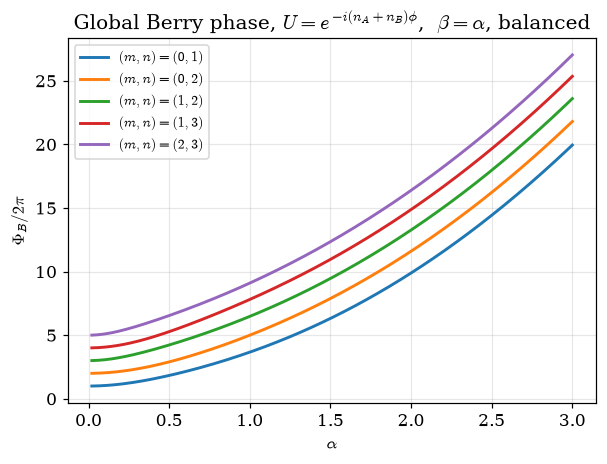

[guardado] figures/fig2_berry_global_indices.pdf


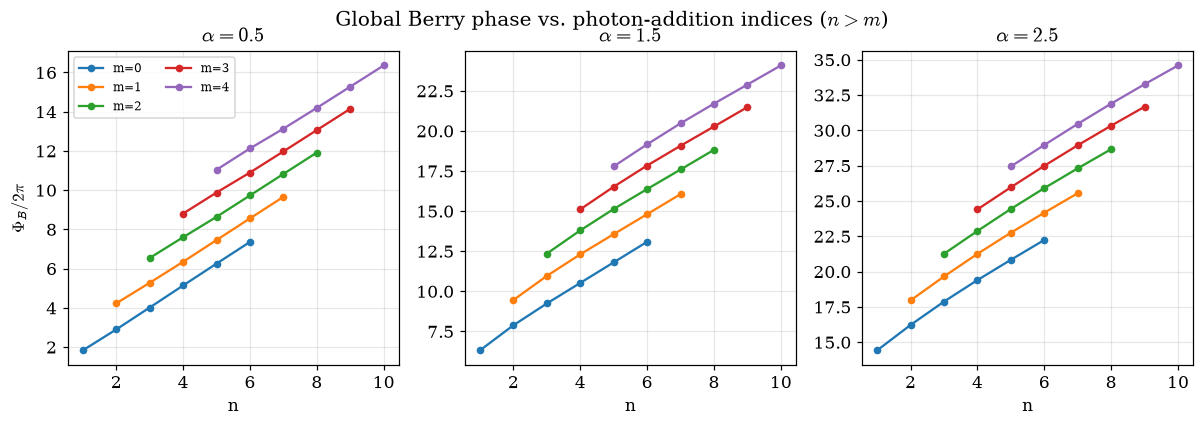

[guardado] figures/fig3_berry_global_chi.pdf


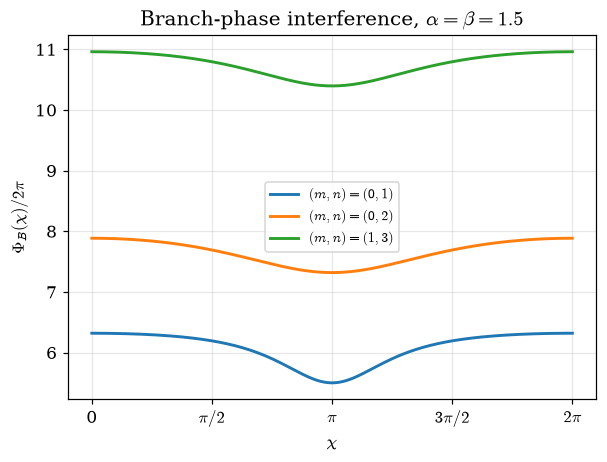

[guardado] figures/fig4_berry_global_map.pdf


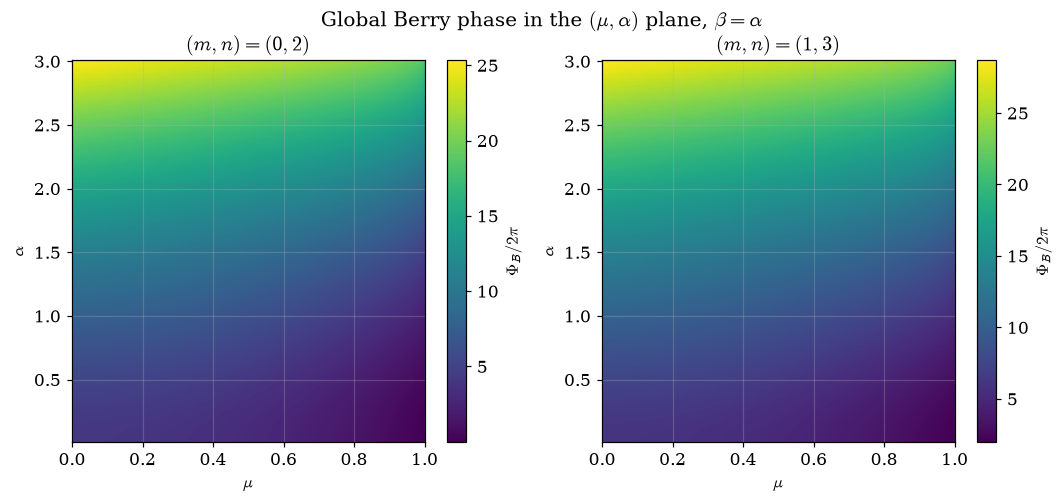

[guardado] figures/fig5_berry_mode_decomposition.pdf


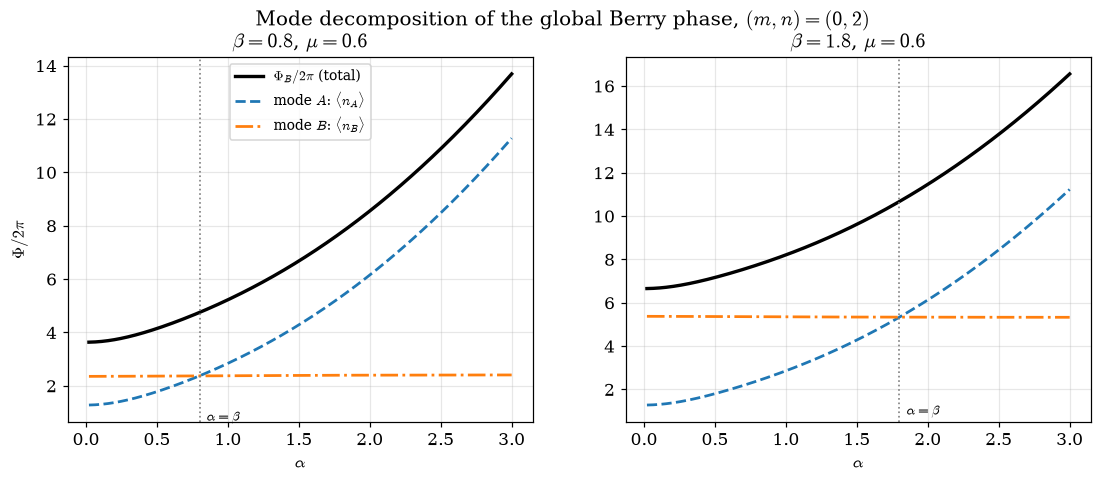

[guardado] figures/fig6_uhlmann_map_A.pdf


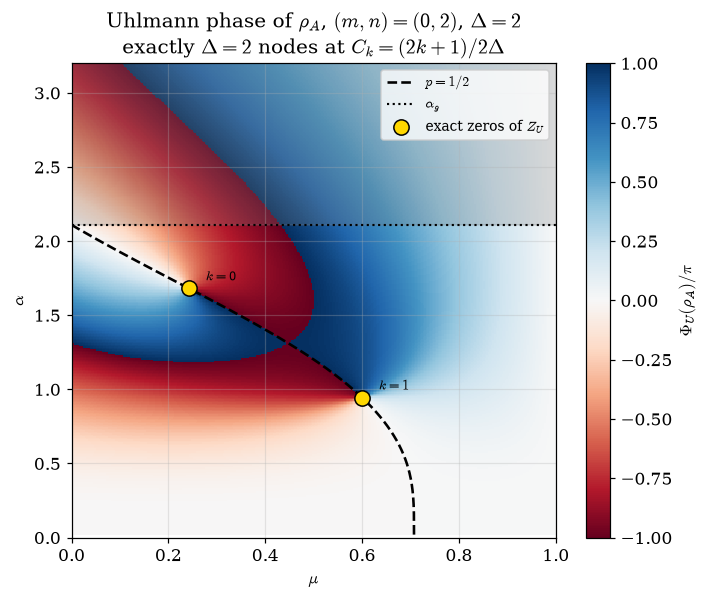

[guardado] figures/fig7_uhlmann_both.pdf


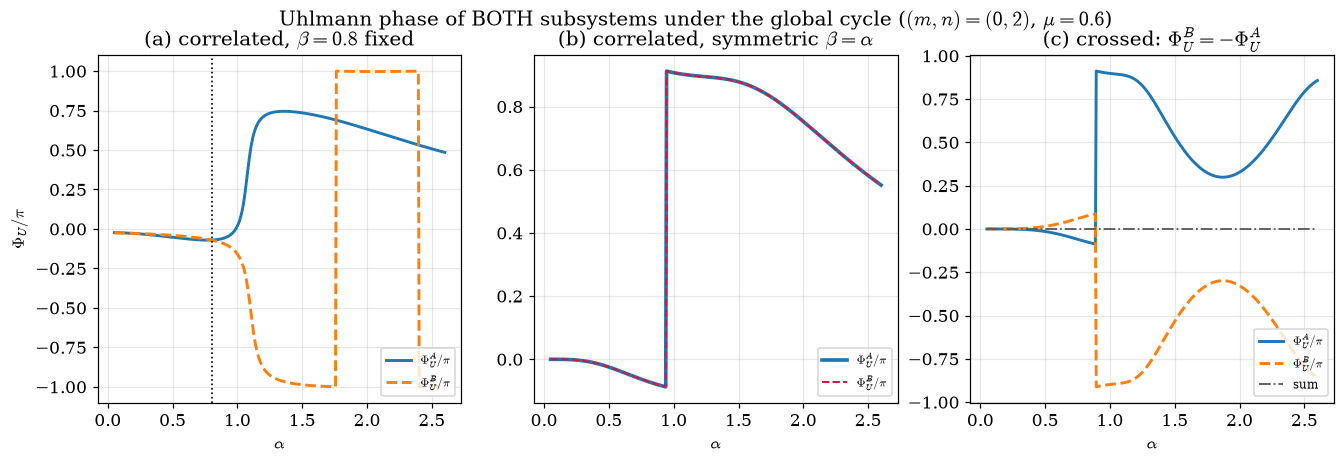

[guardado] figures/fig8_nodes_both.pdf


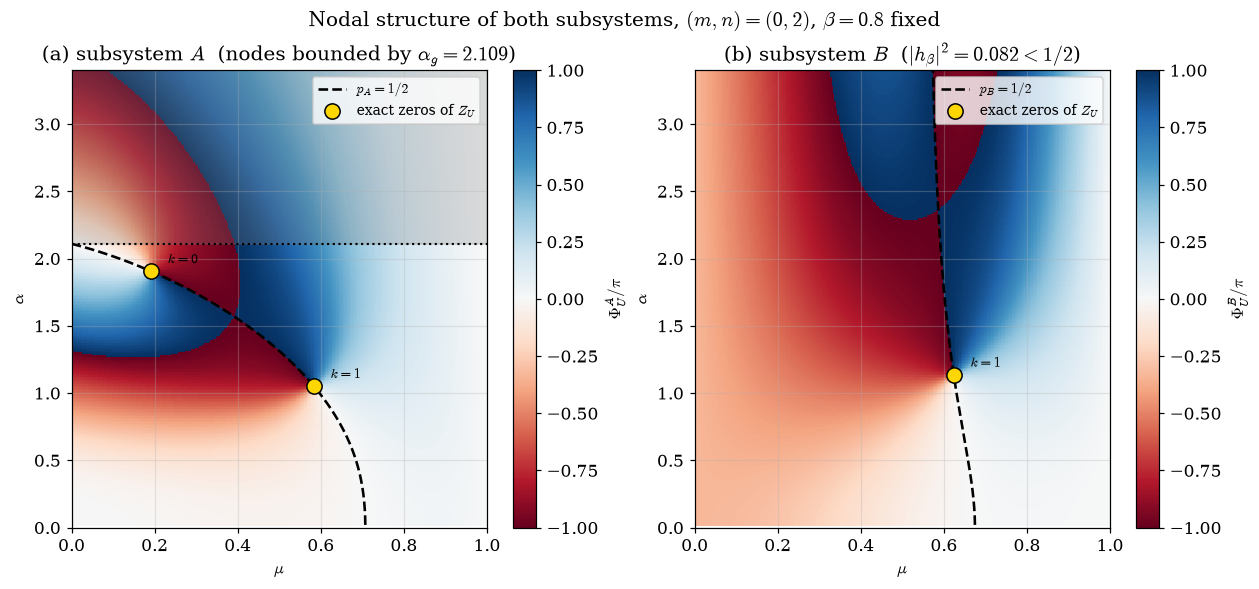

[guardado] figures/fig9_critical_overlap.pdf


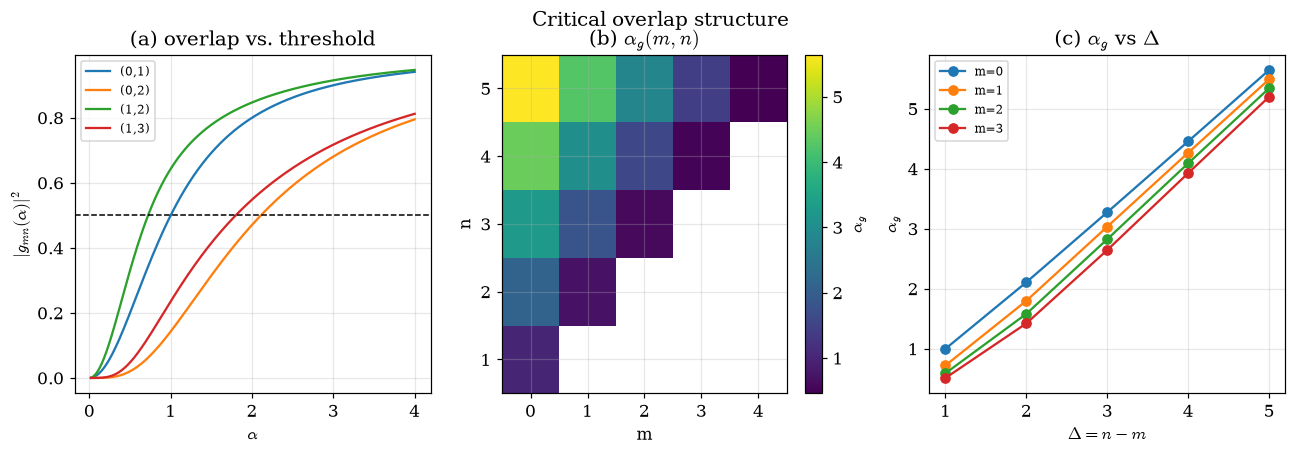

[guardado] figures/fig10_uhlmann_vs_Delta.pdf


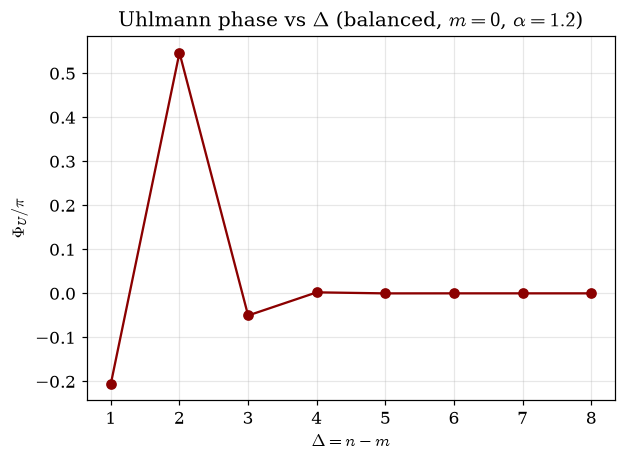

[guardado] figures/fig11_AB_asymmetry.pdf


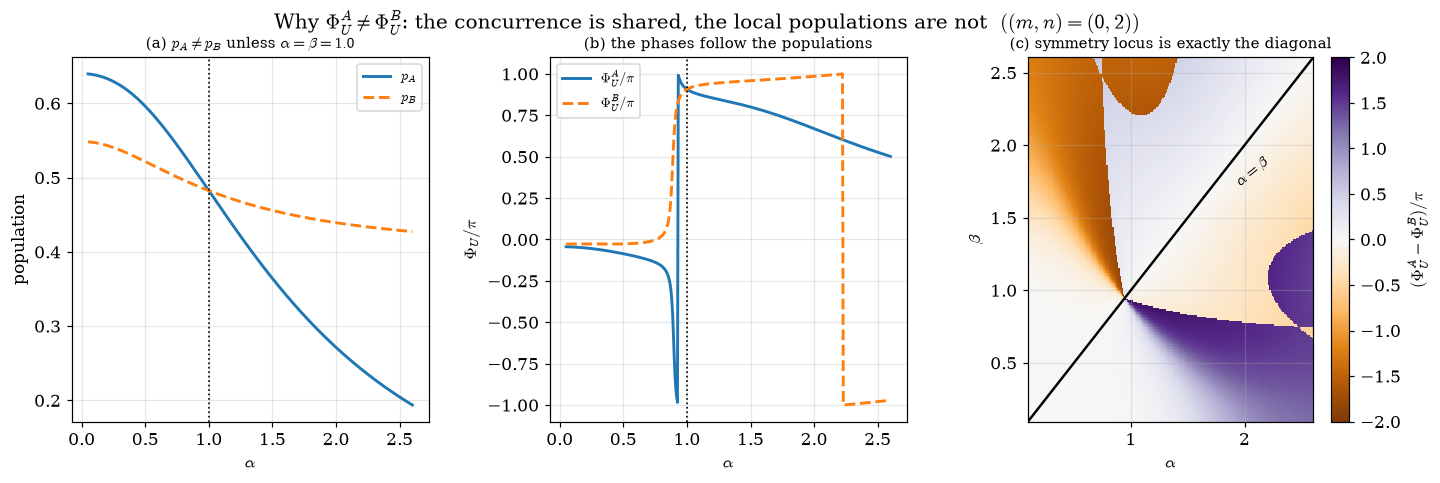

[guardado] figures/fig12_concurrence_pacs.pdf


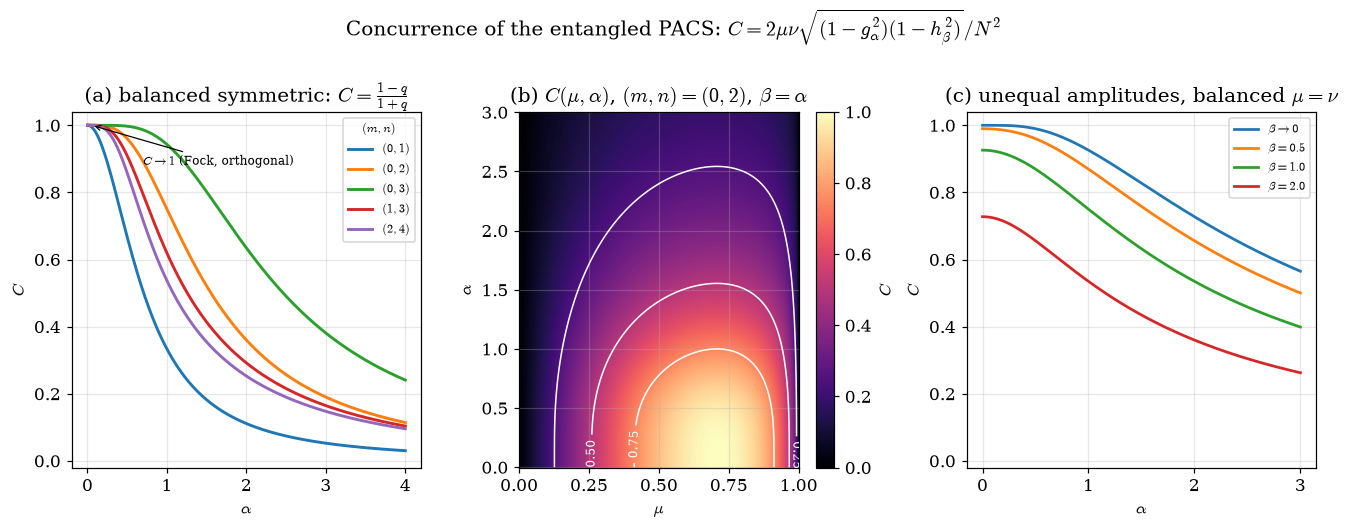

[guardado] figures/fig13_uhlmann_vs_concurrence.pdf


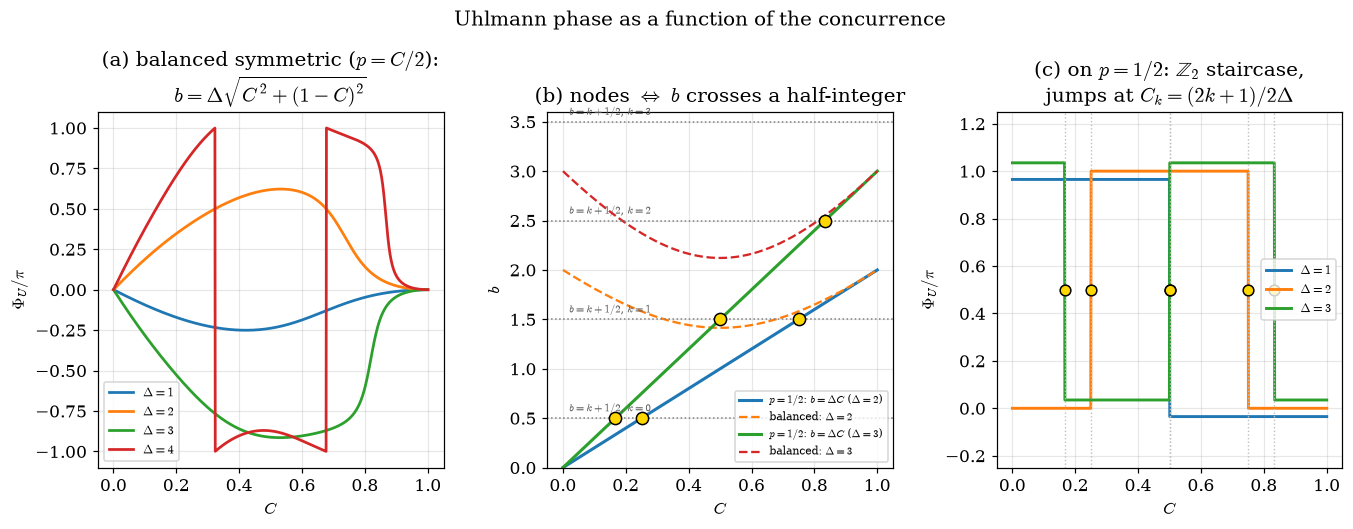

[guardado] figures/fig14_C_eta_plane.pdf


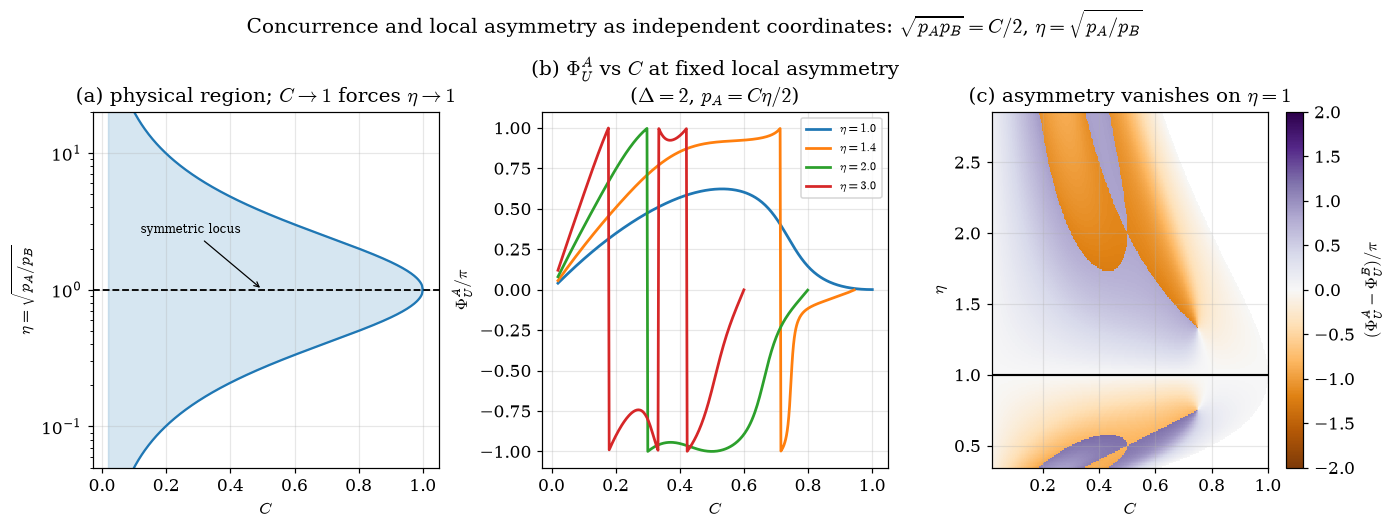


Todas las figuras en: /home/user/prueba/notebook/figures


In [17]:

# ============================================================
# Celda 13 — Regenerar todas las figuras de una vez
# ============================================================
for f in FIGURAS:
    f()
print("\nTodas las figuras en:", os.path.abspath(FIGDIR))



## Referencias

[1] G. S. Agarwal, K. Tara, *Phys. Rev. A* **43**, 492 (1991).
[2] M. V. Berry, *Proc. R. Soc. Lond. A* **392**, 45 (1984).
[3] A. Uhlmann, *Rep. Math. Phys.* **24**, 229 (1986).
[4] W. K. Wootters, *Phys. Rev. Lett.* **80**, 2245 (1998).
[5] F. A. Domínguez-Serna, F. J. Mendieta-Jiménez, F. Rojas, *Quantum Inf. Process.* **15**, 3121 (2016).
[6] S. Mohammadi Almas, G. Najarbashi, A. Tavana, *Int. J. Theor. Phys.* **61**, 192 (2022).
[7] D.-B. Yang, Y. Chen, F.-L. Zhang, J.-L. Chen, *J. Phys. B* **44**, 075502 (2011).
[8] X. Wang, X.-Y. Hou, Z. Zhou, H. Guo, C.-C. Chien, *SciPost Phys. Core* **6**, 024 (2023).
